# Xenium-Supervised Niche Labeling and H&E-Based Prediction for Interpretable Spatial Tissue Analysis

## Abstract
In this tutorial, you will learn how scientists can teach a computer to predict tissue niche types from H&E image-derived features. We use Xenium data only during training to provide biological labels, then train a model that can later predict niche types using H&E-derived features alone. The current notebook uses 12 processed samples: 6 samples for training and 6 samples for held-out validation/testing. You will run marker-gene analysis, GO enrichment analysis (GOEA), LLM-based label naming, and sample-level neural network classification in one reproducible pipeline.

## Core Idea
1. Use WSInsight outputs to get niche groups and H&E-derived features.
2. Use Xenium expression to understand the biology of each niche group.
3. Convert biological interpretation into niche labels.
4. Train a model on 6 samples and test it on the other 6 samples without Xenium at inference time.

## Problem Statement
Given per-cell H&E-derived niche features, learn a function $f_\theta(\cdot)$ that predicts niche subtype labels curated through Xenium-guided biological interpretation. At inference time, Xenium is not required.

**Introduction**

### Why we do this
Spatial transcriptomics can reveal rich biology, but it is expensive and not always available for every slide. H&E is much more scalable, so we want to transfer biological supervision from Xenium into a model that can later run on H&E-derived features alone.

### Scientific contribution
1. We use WSInsight graph-based niche discovery (`wsinsight niche`) to define niche groups from H&E context.
2. We assign biological meaning to each niche via marker genes + GOEA + LLM labeling.
3. We train and validate a supervised classifier that predicts niche subtype using only H&E-derived features.
4. We preserve a strict train/inference separation: Xenium is used to create labels, not for deployment-time prediction.
5. We evaluate on a strict sample-level split of 12 datasets (6 training samples, 6 held-out validation/testing samples).

**Methods Overview (as in a paper)**

### Data and pipeline entrypoints
- H&E slide files: `./data`
- H&E slide manifest: `./data/imagelist.txt`
- Xenium spatial manifest: `./data/sptxlist.tsv`
- Operational script: `./run-wsinsight-all.sh`

### Stage A. Upstream WSInsight processing
1. `wsinsight run`: H&E-based cell prediction
2. `wsinsight niche`: graph-based niche discovery
3. `wsinsight import --include niche`: map Xenium expression to H&E cells

### Stage B. Label construction (training only)
1. Differential marker genes per niche group
2. GOEA for BP/CC/MF biological themes
3. LLM assigns one concise niche label per niche group

### Stage C. Sample-level supervised learning
1. Build niche-level summary vectors from H&E features for each sample
2. Train neural classifier on the 6 training samples only
3. Apply to the 6 held-out samples and report supervised metrics on the seen-label subset, with explicit coverage of excluded rows/samples

### Deployment principle
Use only H&E-derived features for niche prediction. Xenium is used for supervision, not for runtime inference.

## Stage 0: Execute WSInsight Pipeline

> Goal of Stage 0: turn raw H&E-derived cell features into **niche groups** (cell neighborhoods) that later stages can interpret biologically.

This stage creates the imported `.h5ad` outputs used by the rest of the notebook.

Commands run in order:
1. `wsinsight run`
2. `wsinsight niche`
3. `wsinsight import --include niche`

### Big picture (high-school version)
Think of each cell as a student with a report card of numbers (features).
- First, we decide which students are most similar.
- Then, we learn a cleaner representation of those relationships.
- Finally, we group similar students into communities (niches).

So Stage 0 is the "group-building" step. Stages 1-3 depend on these groups.

### Step 1: Build a kNN graph
- `kNN` means **k-nearest neighbors**.
- For each cell, we connect it to its `k` most similar cells.
- Similarity comes from feature vectors (lists of numbers).

Linear-algebra idea (simple):
- A cell vector can be written as $x_i = [x_{i1}, x_{i2}, ..., x_{id}]$.
- One common distance is Euclidean distance:
$$
d(x_i,x_j)=\sqrt{\sum_{m=1}^{d}(x_{im}-x_{jm})^2}
$$
- Smaller distance means "more similar."

Graph idea:
- If cell $j$ is one of cell $i$'s closest neighbors, we add an edge.
- In adjacency-matrix form: $A_{ij}=1$ (connected) or $0$ (not connected).

### Step 2: Learn graph embeddings with DGI
- DGI (Deep Graph Infomax) learns better numeric representations from the graph.
- It compares real neighborhoods to corrupted/shuffled ones.
- It learns vectors that keep meaningful neighborhood structure and reduce noise.

Simple intuition:
- Real neighbor patterns should score high.
- Fake/shuffled patterns should score low.

Why this helps:
- Raw features can be noisy.
- Learned embeddings are usually easier to cluster well.

### Step 3: Group cells into niches (Leiden or KMeans)
#### Leiden (graph community method)
- Works directly on the cell graph.
- Looks for communities with many internal connections and fewer outside connections.
- Good when neighborhood structure is important.

#### KMeans (centroid method)
- Works in embedding space.
- Picks $K$ centers and assigns each cell to the nearest center.
- Then updates centers and repeats.

Linear-algebra idea for KMeans:
$$
\min_{\{\mu_k\}}\sum_{i=1}^{n}\min_{k\in\{1,\dots,K\}}\|x_i-\mu_k\|_2^2
$$
- This means: make each cell as close as possible to its assigned center.

### Why Stage 0 matters
Without Stage 0, we do not have the niche memberships needed for:
1. Marker-gene analysis (Stage 1)
2. GO enrichment and naming (Stage 2)
3. H&E-only niche prediction model (Stage 3)

### What to remember
- kNN: builds the cell-neighbor graph.
- DGI: learns cleaner graph-aware vectors.
- Leiden/KMeans: turns vectors/graph into niche groups.
- Output: niche assignments and niche features stored in imported `.h5ad` files.

Dataset note: this stage prepares all 12 samples. Later, Stage 3 uses a fixed 6-train / 6-held-out split.

In [1]:
# Basic standard-library and data-science imports used throughout the notebook.
# Analogy: these are your toolbox items that will be reused in almost every step.
from pathlib import Path
import os
import numpy as np
import pandas as pd

# -----------------------------
# Global tutorial configuration
# -----------------------------
# Full fixed cohort of 12 samples for this notebook.
all_sample_stems = [
    "Human_Breast_Biomarkers_S1_Top_he_image.ome",
    "Human_Breast_Biomarkers_S1_Mid_he_image.ome",
    "Human_Breast_Biomarkers_S1_Bot_he_image.ome",
    "Human_Breast_Biomarkers_S2_Top_he_image.ome",
    "Human_Breast_Biomarkers_S2_Mid_he_image.ome",
    "Human_Breast_Biomarkers_S2_Bot_he_image.ome",
    "Human_Breast_Biomarkers_S3_Top_he_image.ome",
    "Human_Breast_Biomarkers_S3_Mid_he_image.ome",
    "Human_Breast_Biomarkers_S3_Bot_he_image.ome",
    "Human_Breast_Biomarkers_S4_Top_he_image.ome",
    "Human_Breast_Biomarkers_S4_Mid_he_image.ome",
    "Human_Breast_Biomarkers_S4_Bot_he_image.ome",
]

# Fixed training subset (6 samples).
train_sample_stems = [
    "Human_Breast_Biomarkers_S1_Top_he_image.ome",
    "Human_Breast_Biomarkers_S1_Mid_he_image.ome",
    "Human_Breast_Biomarkers_S1_Bot_he_image.ome",
    "Human_Breast_Biomarkers_S2_Top_he_image.ome",
    "Human_Breast_Biomarkers_S2_Mid_he_image.ome",
    "Human_Breast_Biomarkers_S2_Bot_he_image.ome",
]

# Held-out subset is "all minus train".
test_sample_stems = [s for s in all_sample_stems if s not in train_sample_stems]

# Output version selector for this run.
outputs_version = "v3"
outputs_root = Path("outputs") / outputs_version

# Folder containing per-sample imported .h5ad files from WSInsight import stage.
imported_xenium_dir = outputs_root / "imported-xenium"

# Central configuration dictionary so later cells can reuse the same settings.
CFG = {
    "slides_dir": Path("data"),
    "image_list_txt": Path("data/imagelist.txt"),
    "sptx_map_tsv": Path("data/sptxlist.tsv"),
    "run_script": Path("run-wsinsight-all.sh"),
    "outputs_version": outputs_version,
    "outputs_root": outputs_root,
    "imported_xenium_dir": imported_xenium_dir,
    "sample_split_dir": outputs_root / "nn_sample_split",
    "all_sample_stems": all_sample_stems,
    "train_sample_stems": train_sample_stems,
    "test_sample_stems": test_sample_stems,
    "train_sample_count": len(train_sample_stems),
    "test_sample_count": len(test_sample_stems),
    "outdir": outputs_root / "goea_multi_niche",
    "seed": 42,
    "cells_per_draw": 100,
    "nn_epochs": 40,
    "nn_batch_size": 128,
    "nn_lr": 1e-3,
    "nn_weight_decay": 1e-4,
}

# Set NumPy random seed for reproducible random operations.
np.random.seed(CFG["seed"])
# Create output directories now so later save operations do not fail.
CFG["outdir"].mkdir(parents=True, exist_ok=True)
CFG["sample_split_dir"].mkdir(parents=True, exist_ok=True)

# Print a readable summary so users can verify configuration quickly.
print("Configuration loaded.")
print("Outputs version:", CFG["outputs_version"])
print("All samples:", len(CFG["all_sample_stems"]))
print(pd.Series({k: str(v) for k, v in CFG.items() if "dir" in k or "txt" in k or "tsv" in k or "script" in k or "root" in k}).to_string())
print("Training samples:", CFG["train_sample_stems"])
print("Held-out test samples:", CFG["test_sample_stems"])


Configuration loaded.
Outputs version: v3
All samples: 12
slides_dir                                    data
image_list_txt                  data/imagelist.txt
sptx_map_tsv                     data/sptxlist.tsv
run_script                    run-wsinsight-all.sh
outputs_root                            outputs/v3
imported_xenium_dir     outputs/v3/imported-xenium
sample_split_dir        outputs/v3/nn_sample_split
outdir                 outputs/v3/goea_multi_niche
Training samples: ['Human_Breast_Biomarkers_S1_Top_he_image.ome', 'Human_Breast_Biomarkers_S1_Mid_he_image.ome', 'Human_Breast_Biomarkers_S1_Bot_he_image.ome', 'Human_Breast_Biomarkers_S2_Top_he_image.ome', 'Human_Breast_Biomarkers_S2_Mid_he_image.ome', 'Human_Breast_Biomarkers_S2_Bot_he_image.ome']
Held-out test samples: ['Human_Breast_Biomarkers_S3_Top_he_image.ome', 'Human_Breast_Biomarkers_S3_Mid_he_image.ome', 'Human_Breast_Biomarkers_S3_Bot_he_image.ome', 'Human_Breast_Biomarkers_S4_Top_he_image.ome', 'Human_Breast_Biomark

**WSInsight Stage Output**
What you should see: either live execution logs (if `RUN_WSINSIGHT=True`) or a printed command sequence (default).

Generated outputs expected under `outputs/v3/`:
- cell predictions from `wsinsight run`
- niche assignments/features from `wsinsight niche`
- imported Xenium-linked outputs from `wsinsight import --include niche`

Important carry-forward artifacts for this notebook:
- 12 Xenium-imported per-sample h5ad files in `outputs/v3/imported-xenium/`
- niche membership columns
- normalized niche feature columns

Split note: these 12 samples are later split into 6 training samples and 6 held-out validation/testing samples.

**How To Run This Notebook (Step-by-Step)**
1. Run cells from top to bottom in order. Do not skip cells.
2. If a cell fails, fix that error first, then continue.
3. Keep the data paths unchanged unless your files are in a different location.
4. Do not run DE/GOEA cells before normalization/log1p is completed.
5. Save outputs at each stage; they are reused later in the pipeline.

### Expected outcome
By the end, you will train and evaluate a model that predicts niche labels from H&E-derived features on a 12-sample cohort with a strict split: 6 training samples and 6 held-out validation/testing samples.

### Install Dependencies
Installs required Python packages for the tutorial environment. If your environment already has these packages, you can skip this cell.

In [2]:
# Install required packages into the current notebook Python environment.
# Analogy: this is like stocking your kitchen with all ingredients before cooking.
# -q means quiet mode (less terminal output).
# You usually run this once per new environment.
%pip install -q goatools mygene openai python-dotenv scanpy seaborn scikit-learn torch

Note: you may need to restart the kernel to use updated packages.


### Dependency Installation
What you should see: package installation logs from pip, or "already satisfied" messages.

Generated files: none in this workspace notebook flow.

Important carry-forward state:
- The Python environment now includes required libraries (`scanpy`, `goatools`, `mygene`, `openai`, `torch`, etc.), enabling all later imports.

### Configuration
What you should see: "Configuration loaded", the 12 total samples, the 6 training samples, the 6 held-out test samples, and a printed table of key paths.

Generated files/folders:
- Ensures `outputs/v3/goea_multi_niche/` exists.
- Ensures `outputs/v3/nn_sample_split/` exists.

Important carry-forward variables:
- `CFG`: central configuration dictionary used by all downstream cells.
- `CFG["all_sample_stems"]`: the full list of 12 datasets.
- `CFG["train_sample_stems"]`: the 6 training datasets.
- `CFG["test_sample_stems"]`: the 6 held-out datasets.
- `CFG["slides_dir"]`: directory containing the slide files used by the manifest.
- `CFG["image_list_txt"]`: the H&E slide list manifest (`data/imagelist.txt`).
- `CFG["sptx_map_tsv"]`: the Xenium spatial manifest (`data/sptxlist.tsv`).
- `CFG["imported_xenium_dir"]`: directory that stores the 12 per-sample imported h5ad files.
- Global random seed (`np.random.seed(CFG["seed"])`) for reproducibility.

In [3]:
# Check key input paths and summarize availability.
# This is informational only and does not stop notebook execution.
required_paths = [
    CFG["slides_dir"],
    CFG["image_list_txt"],
    CFG["sptx_map_tsv"],
    CFG["imported_xenium_dir"],
]

existing_paths = [p for p in required_paths if p.exists()]
missing_paths = [p for p in required_paths if not p.exists()]

print("Input path check:")
print(f"- Existing: {len(existing_paths)}")
print(f"- Missing: {len(missing_paths)}")
if missing_paths:
    print("Missing paths:")
    for p in missing_paths:
        print(" ", p)

# Load mapping table when available.
map_df = pd.DataFrame(columns=["sptx_path", "sample_id"])
if CFG["sptx_map_tsv"].exists():
    map_df = pd.read_csv(CFG["sptx_map_tsv"], sep="\t", header=None, names=["sptx_path", "sample_id"])
    print("\nSample mapping preview:")
    if map_df.empty:
        print("Mapping table is empty.")
    else:
        print(map_df.head().to_string(index=False))
    print(f"\nTotal mapping rows: {len(map_df)}")
else:
    print("\nMapping table not found:", CFG["sptx_map_tsv"])

# Report imported h5ad availability without raising errors.
expected_h5ad_paths = [CFG["imported_xenium_dir"] / f"{stem}.h5ad" for stem in CFG["all_sample_stems"]]
available_h5ad = [p for p in expected_h5ad_paths if p.exists()]
missing_h5ad = [p for p in expected_h5ad_paths if not p.exists()]
print(f"Imported h5ad files available: {len(available_h5ad)} / {len(expected_h5ad_paths)}")
if missing_h5ad:
    print("Missing imported h5ad files:")
    for p in missing_h5ad:
        print(" ", p)

Input path check:
- Existing: 4
- Missing: 0

Sample mapping preview:
                                          sptx_path                                   sample_id
/workspace/data/Human_Breast_Biomarkers_S1_Top_outs Human_Breast_Biomarkers_S1_Top_he_image.ome
/workspace/data/Human_Breast_Biomarkers_S1_Bot_outs Human_Breast_Biomarkers_S1_Bot_he_image.ome
/workspace/data/Human_Breast_Biomarkers_S2_Top_outs Human_Breast_Biomarkers_S2_Top_he_image.ome
/workspace/data/Human_Breast_Biomarkers_S2_Mid_outs Human_Breast_Biomarkers_S2_Mid_he_image.ome
/workspace/data/Human_Breast_Biomarkers_S2_Bot_outs Human_Breast_Biomarkers_S2_Bot_he_image.ome

Total mapping rows: 12
Imported h5ad files available: 12 / 12


**Input Validation and Sample Mapping**
What you should see: confirmation that required paths exist, a preview of `data/sptxlist.tsv`, and total mapping row count.

Generated files: none.

Important carry-forward variables:
- `map_df`: image-to-spatial mapping table loaded from `data/sptxlist.tsv`.

## Pipeline Map: Train Time vs Inference Time

### Train time (this notebook)
1. Run WSInsight pipeline (`run-wsinsight-all.sh`) to get H&E cell outputs, niche-group outputs, and Xenium import data.
2. Use Xenium expression to compute marker genes per niche group.
3. Use GOEA to summarize biology (BP, CC, MF).
4. Use LLM to assign a short niche label to each niche group.
5. Build sample-level vectors for all 12 samples, train only on 6 samples, and validate/test on the other 6 samples.

### Inference time (future deployment)
Only H&E-derived features are needed. Xenium is not required.

This is the key design: Xenium provides supervision labels; H&E model provides scalable prediction.

**Stage 0: WSInsight Graph Construction from H&E**

### Why this stage matters
This is the foundation of the notebook. It creates the niche groups and feature columns used by every later biological and machine-learning step.

### What happens here (simple flow)
1. Run WSInsight pipeline (`run-wsinsight-all.sh`).
2. Generate imported outputs for the full 12-sample cohort.
3. Load and combine all 12 imported `.h5ad` files into one cohort object for interpretation.
4. Reuse this cohort later with a strict split: 6 training samples and 6 held-out samples.

### Student-friendly intuition
- Stage 0 is like organizing a huge class into study groups based on who is similar and who interacts with whom.
- Later stages ask: "What biology does each group represent?" and "Can we predict those groups from H&E features alone?"

In [4]:
# Import libraries needed for plotting, Scanpy processing, and GO enrichment analysis.
# Analogy: this is laying out all lab instruments on the bench before the experiment starts.
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import mygene

from goatools.base import download_go_basic_obo, download_ncbi_associations
from goatools.obo_parser import GODag
from goatools.anno.genetogo_reader import Gene2GoReader
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS

# Make Scanpy output less noisy and figures readable in notebook.
sc.settings.verbosity = 1
sc.set_figure_params(dpi=110, frameon=False)

# MyGene client used later to map gene symbols to Entrez IDs for GOEA.
mg = mygene.MyGeneInfo()
print("Imports ready.")

Imports ready.


**Library Imports**
What you should see: "Imports ready." with no import errors.

Generated files: none.

Important carry-forward variables/objects:
- `sc` (Scanpy module) with plotting settings applied.
- `mg` (`mygene.MyGeneInfo()` client), reused for gene ID mapping in GOEA preparation.

### Next: Load and Concatenate the 12 Imported h5ad Files
Loads all 12 Xenium-imported h5ad files from `outputs/v3/imported-xenium/`, concatenates them into one cohort AnnData (`adata_work`), and keeps per-cell `sample_id` metadata for cohort-level DE/GOEA/label construction.

In [5]:
# Load and concatenate all 12 imported AnnData objects into one cohort object.
# Analogy: this is like combining 12 separate spreadsheets into one master workbook.
# This unified object is used for cohort-level interpretation steps.
expected_h5ad_paths = [CFG["imported_xenium_dir"] / f"{stem}.h5ad" for stem in CFG["all_sample_stems"]]
cohort_adatas = []

# Read each sample file and attach sample_id so we can track origin after concatenation.
for stem, path in zip(CFG["all_sample_stems"], expected_h5ad_paths):
    print(f"Loading {stem}: {path}")
    ad = sc.read_h5ad(path)
    ad.obs = ad.obs.copy()
    ad.obs["sample_id"] = stem
    cohort_adatas.append(ad)

# Concatenate samples into one AnnData.
# join="inner" keeps only shared variables across all samples.
adata = sc.concat(
    cohort_adatas,
    join="inner",
    merge="same",
    label="cohort_key",
    keys=CFG["all_sample_stems"],
    index_unique="__",
)

# Keep a working copy to safely modify in downstream steps.
adata_work = adata.copy()

# Educational mode: warn instead of hard-failing if sample count is unexpected.
n_samples_loaded = int(adata_work.obs["sample_id"].nunique())
if n_samples_loaded != len(CFG["all_sample_stems"]):
    print(
        "Warning: cohort sample-count mismatch. "
        f"Expected {len(CFG['all_sample_stems'])}, got {n_samples_loaded}. "
        "Continuing for learning/demo purposes."
    )

# Print useful summary information for quick inspection.
print("Cohort AnnData loaded.")
print("Samples in cohort:", n_samples_loaded)
print(adata)
print("obs columns:", len(adata_work.obs.columns))
print("var genes:", adata_work.n_vars)
print("cells:", adata_work.n_obs)
print(adata_work.obs["sample_id"].value_counts().sort_index().to_string())

Loading Human_Breast_Biomarkers_S1_Top_he_image.ome: outputs/v3/imported-xenium/Human_Breast_Biomarkers_S1_Top_he_image.ome.h5ad
Loading Human_Breast_Biomarkers_S1_Mid_he_image.ome: outputs/v3/imported-xenium/Human_Breast_Biomarkers_S1_Mid_he_image.ome.h5ad
Loading Human_Breast_Biomarkers_S1_Bot_he_image.ome: outputs/v3/imported-xenium/Human_Breast_Biomarkers_S1_Bot_he_image.ome.h5ad
Loading Human_Breast_Biomarkers_S2_Top_he_image.ome: outputs/v3/imported-xenium/Human_Breast_Biomarkers_S2_Top_he_image.ome.h5ad
Loading Human_Breast_Biomarkers_S2_Mid_he_image.ome: outputs/v3/imported-xenium/Human_Breast_Biomarkers_S2_Mid_he_image.ome.h5ad
Loading Human_Breast_Biomarkers_S2_Bot_he_image.ome: outputs/v3/imported-xenium/Human_Breast_Biomarkers_S2_Bot_he_image.ome.h5ad
Loading Human_Breast_Biomarkers_S3_Top_he_image.ome: outputs/v3/imported-xenium/Human_Breast_Biomarkers_S3_Top_he_image.ome.h5ad
Loading Human_Breast_Biomarkers_S3_Mid_he_image.ome: outputs/v3/imported-xenium/Human_Breast_Biom

**AnnData Loaded**
What you should see: cohort AnnData summary, number of `obs` columns, number of genes, total cell count, and per-sample cell counts across all 12 samples.

Generated files: none.

Important carry-forward variables:
- `adata`: concatenated cohort AnnData across all 12 imported samples.
- `adata_work`: working copy used and modified in downstream cohort-level interpretation steps.

### Critical Preprocessing Warning
Normalization and log1p are mandatory before marker-gene testing and GOEA. Skipping this step can invalidate downstream biological interpretation.

In [6]:
# Preprocessing for differential expression and GOEA.
# Analogy: this is like cleaning and standardizing ingredients before any recipe step.
# Goal: keep raw counts, then apply normalize_total + log1p exactly once.
if "sample_id" not in adata_work.obs.columns:
    print("Warning: sample_id metadata missing. Creating a fallback sample_id='unknown'.")
    adata_work.obs = adata_work.obs.copy()
    adata_work.obs["sample_id"] = "unknown"

if adata_work.obs["sample_id"].nunique() != len(CFG["all_sample_stems"]):
    print(
        "Warning: preprocessing expected all configured samples, but counts differ. "
        "Continuing for educational flow."
    )

# Compute QC metrics. percent_top=None avoids top-N proportion metrics; log1p=False uses raw values.
sc.pp.calculate_qc_metrics(adata_work, percent_top=None, log1p=False, inplace=True)

# Preserve original matrix in a layer for traceability/reproducibility.
if "counts" not in adata_work.layers:
    adata_work.layers["counts"] = adata_work.X.copy()

# Avoid accidental double-normalization by checking if log1p metadata already exists.
if "log1p" not in adata_work.uns:
    sc.pp.normalize_total(adata_work, target_sum=1e4)
    sc.pp.log1p(adata_work)
    print("Applied normalize_total + log1p.")
else:
    print("Data already appears log-normalized; skipped re-normalization.")

print("Cells:", adata_work.n_obs, "Genes:", adata_work.n_vars)

/home/leiah/.conda/envs/spie2027/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


Applied normalize_total + log1p.
Cells: 3442976 Genes: 280


### Preprocessing
What you should see: message indicating whether `normalize_total + log1p` was applied or skipped, plus cell/gene counts.

Generated files: none.

Important carry-forward state/variables:
- `adata_work` is updated in place.
- `adata_work.layers["counts"]` stores original counts (if not already present).
- Normalized/log-transformed matrix in `adata_work.X` is ready for DE and GOEA steps.

In [7]:
# Detect niche membership columns and normalized feature columns automatically.
# Analogy: this is like scanning a form to find the exact columns you need before calculations.
niche_list = sorted(
    [c for c in adata_work.obs.columns if c.startswith("niche_") and c[6:].isnumeric()],
    key=lambda x: int(x.split("_")[1]),
)
feature_cols = sorted([c for c in adata_work.obs.columns if c.startswith("niche_feature_normalized_")])

if not niche_list:
    raise RuntimeError("No niche_* membership columns found.")
if not feature_cols:
    raise RuntimeError("No niche_feature_normalized_* feature columns found.")

# Print summary to confirm expected columns are present.
print(f"Detected {len(niche_list)} niche groups")
print(f"Detected {len(feature_cols)} normalized niche features")
print("First 10 niche-group columns:", niche_list[:10])
print("Feature columns:", feature_cols)

Detected 10 niche groups
Detected 18 normalized niche features
First 10 niche-group columns: ['niche_0', 'niche_1', 'niche_2', 'niche_3', 'niche_4', 'niche_5', 'niche_6', 'niche_7', 'niche_8', 'niche_9']
Feature columns: ['niche_feature_normalized_k0_background', 'niche_feature_normalized_k0_connective', 'niche_feature_normalized_k0_dead', 'niche_feature_normalized_k0_epithelial', 'niche_feature_normalized_k0_inflammatory', 'niche_feature_normalized_k0_neoplastic', 'niche_feature_normalized_k1_background', 'niche_feature_normalized_k1_connective', 'niche_feature_normalized_k1_dead', 'niche_feature_normalized_k1_epithelial', 'niche_feature_normalized_k1_inflammatory', 'niche_feature_normalized_k1_neoplastic', 'niche_feature_normalized_k2_background', 'niche_feature_normalized_k2_connective', 'niche_feature_normalized_k2_dead', 'niche_feature_normalized_k2_epithelial', 'niche_feature_normalized_k2_inflammatory', 'niche_feature_normalized_k2_neoplastic']


**Niche and Feature Columns**
What you should see: counts of detected niche groups and normalized niche features, plus example column names.

Generated files: none.

Important carry-forward variables:
- `niche_list`: niche membership columns used to define niche groups in later loops.
- `feature_cols`: normalized niche feature columns used for vector construction and model training.

**Stage 1: Build Biological Supervision Labels from Xenium**

### Rationale
Niche groups are computational clusters from H&E-based graph learning. To attach biological meaning, we transfer information from Xenium expression through marker genes and GO enrichment, then ask an LLM to produce one short niche label per group.

### Procedure
1. Differential expression per niche group: in-group (membership = 1) vs out-group (all others).
2. GOEA over marker sets to identify significant BP/CC/MF biological themes.
3. LLM labeling to convert enriched themes into concise niche subtype names.

### Output
`niche_labels_by_niche.csv` provides supervision targets for H&E-only model training.

### Important separation
Xenium is used only to create training labels. The final predictive model runs on H&E-derived features only.

Split note: Stage 1 and Stage 2 use only the 6 training samples to define supervision labels; Stage 3 applies those labels to all 12 samples with a fixed 6 training / 6 held-out split.

### Run Differential Expression
Performs differential expression for each niche group (in-group vs out-group) on the training-only AnnData cohort (6 samples), then saves full and filtered marker-gene tables.

Math used in this step: for each gene $g$, we compare expression between in-group and out-group and estimate a test statistic and adjusted p-value.

Filter rule applied after testing:
$$
p_{adj}(g) < 0.05,\quad \log_2 FC(g) > 0.25
$$
Only genes passing both thresholds are kept as marker genes for downstream GOEA.

In [8]:
# Prepare the train-only cohort for marker-gene testing.
# Analogy: this is like choosing only the training slides before measuring which genes stand out.
from tqdm.auto import tqdm

# Educational mode fallback for missing sample_id.
if "sample_id" not in adata_work.obs.columns:
    print(
        "Warning: adata_work is missing sample_id. "
        "Using the full cohort as label-construction data for this demo run."
    )
    adata_label_work = adata_work.copy()
    label_train_stems = set()
else:
    # Build train-only AnnData for label construction (strict split discipline).
    label_train_stems = set(CFG["train_sample_stems"])
    label_train_mask = adata_work.obs["sample_id"].isin(label_train_stems)
    adata_label_work = adata_work[label_train_mask].copy()

# Verify expected number of train samples in the label-construction cohort.
n_label_samples = int(adata_label_work.obs["sample_id"].nunique()) if "sample_id" in adata_label_work.obs.columns else 0
if label_train_stems and n_label_samples != len(label_train_stems):
    print(
        "Warning: label-construction cohort mismatch. "
        f"Expected {len(label_train_stems)} train samples, got {n_label_samples}. "
        "Continuing for educational flow."
    )

# Minimum number of positive/negative cells required for stable DE testing.
min_positive_cells = 20
all_marker_tables = []
marker_summary = []

### Marker-Gene Setup (Beginner Notes)
In this stage, we compare two cell populations for each niche group:
1. In-group: cells where that niche membership equals 1.
2. Out-group: all other cells.

What DE means here: for each gene, we test whether expression is systematically higher in the in-group than in the out-group.

Why this matters biologically:
- If a gene is consistently higher in one niche, it can be a marker for the biology of that microenvironment.
- Marker genes are the bridge from computational niche labels to biological interpretation.

Important statistical idea:
- We test many genes, so we use adjusted p-values (multiple-testing correction).
- Later we keep genes that satisfy both statistical significance and practical effect size.

This cell only prepares data objects; the next cell performs the DE tests.

In [9]:
# Differential expression (DE) across all detected niche groups.
#
# Learning goal for beginners:
# For each niche group, compare gene expression in two sets of cells:
#   - in-group cells: membership == 1
#   - out-group cells: membership != 1
# If a gene is much higher in the in-group and statistically significant,
# that gene is a candidate marker for the niche biology.

# Cache paths so repeated runs can skip expensive DE recomputation.
markers_all_path = CFG["outdir"] / "markers_all_niche.csv"
markers_filt_path = CFG["outdir"] / "markers_filt_niche.csv"
marker_summary_path = CFG["outdir"] / "marker_summary_by_niche.csv"
marker_cache_meta_path = CFG["outdir"] / "marker_de_cache_meta.csv"

cache_meta_now = {
    "train_samples": "|".join(sorted(label_train_stems)),
    "niche_groups": "|".join(niche_list),
    "min_positive_cells": int(min_positive_cells),
    "label_cells": int(adata_label_work.n_obs),
}

use_cache = False
if markers_all_path.exists() and markers_filt_path.exists() and marker_summary_path.exists() and marker_cache_meta_path.exists():
    try:
        cache_meta_old = pd.read_csv(marker_cache_meta_path)
        if not cache_meta_old.empty:
            row = cache_meta_old.iloc[0].to_dict()
            use_cache = (
                str(row.get("train_samples", "")) == cache_meta_now["train_samples"]
                and str(row.get("niche_groups", "")) == cache_meta_now["niche_groups"]
                and int(row.get("min_positive_cells", -1)) == cache_meta_now["min_positive_cells"]
                and int(row.get("label_cells", -1)) == cache_meta_now["label_cells"]
            )
    except Exception:
        use_cache = False

if use_cache:
    markers_all = pd.read_csv(markers_all_path)
    markers_filt_all = pd.read_csv(markers_filt_path)
    marker_summary_df = pd.read_csv(marker_summary_path)
    print("Loaded cached marker DE tables from disk.")
else:
    # Reset containers each run so repeated execution does not duplicate results.
    all_marker_tables = []
    marker_summary = []

    # We loop over every detected niche, so this is never hardcoded to 5 or 10.
    for niche_col in tqdm(niche_list, desc="Marker DE by niche group", unit="group"):
        # Build boolean masks for in-group and out-group.
        pos_mask = adata_label_work.obs[niche_col].fillna(0).astype(int).eq(1)
        n_pos = int(pos_mask.sum())
        n_neg = int((~pos_mask).sum())

        # We skip tiny groups because statistical tests become unstable
        # when one side has too few cells.
        if n_pos < min_positive_cells or n_neg < min_positive_cells:
            marker_summary.append({"niche_group": niche_col, "n_pos": n_pos, "n_neg": n_neg, "status": "skipped_small_group"})
            continue

        # group_col is a temporary label used by Scanpy to define two classes.
        group_col = f"{niche_col}_group"
        key_added = f"de_{niche_col}"
        adata_label_work.obs[group_col] = pd.Categorical(np.where(pos_mask, "in", "out"), categories=["in", "out"])

        # Wilcoxon rank-sum compares expression rank distributions between groups.
        # It is non-parametric: it does not assume expression follows a normal curve.
        sc.tl.rank_genes_groups(
            adata_label_work,
            groupby=group_col,
            groups=["in"],
            reference="out",
            method="wilcoxon",
            pts=True,
            key_added=key_added,
        )

        # Convert DE output into a table and tag which niche produced it.
        mk = sc.get.rank_genes_groups_df(adata_label_work, group="in", key=key_added)
        mk["niche_group"] = niche_col
        mk["n_pos"] = n_pos
        mk["n_neg"] = n_neg
        all_marker_tables.append(mk)
        marker_summary.append({"niche_group": niche_col, "n_pos": n_pos, "n_neg": n_neg, "status": "ok"})

    # Combine DE tables from all niches.
    markers_all = pd.concat(all_marker_tables, ignore_index=True) if all_marker_tables else pd.DataFrame()

    # Keep genes that pass both:
    #   1) adjusted p-value < 0.05 (statistical significance after correction)
    #   2) log fold change > 0.25 (practical effect size threshold)
    markers_filt_all = (
        markers_all.query("pvals_adj < 0.05 and logfoldchanges > 0.25").copy()
        if not markers_all.empty else pd.DataFrame()
    )
    marker_summary_df = pd.DataFrame(marker_summary)

    # Save reproducible outputs for downstream GOEA and label construction.
    markers_all.to_csv(markers_all_path, index=False)
    markers_filt_all.to_csv(markers_filt_path, index=False)
    marker_summary_df.to_csv(marker_summary_path, index=False)
    pd.DataFrame([cache_meta_now]).to_csv(marker_cache_meta_path, index=False)
    print("Computed marker DE and refreshed cache on disk.")

# QC output: print complete per-niche summary (not just head).
n_niches_detected = len(niche_list)
n_niches_tested_ok = int((marker_summary_df["status"] == "ok").sum()) if not marker_summary_df.empty and "status" in marker_summary_df.columns else 0
n_niches_skipped = int((marker_summary_df["status"] != "ok").sum()) if not marker_summary_df.empty and "status" in marker_summary_df.columns else 0

print("Label-construction samples:", sorted(label_train_stems))
print(f"Niche groups detected: {n_niches_detected}")
print(f"Niche groups tested successfully: {n_niches_tested_ok}")
print(f"Niche groups skipped (too few cells): {n_niches_skipped}")
print("\nPer-niche DE summary:")
print(marker_summary_df.to_string(index=False))
print("\nTotal marker rows:", len(markers_all))
print("Filtered marker rows:", len(markers_filt_all))
print("Samples represented for label construction:", adata_label_work.obs["sample_id"].nunique())
print("Marker DE cache metadata:", marker_cache_meta_path)

Loaded cached marker DE tables from disk.
Label-construction samples: ['Human_Breast_Biomarkers_S1_Bot_he_image.ome', 'Human_Breast_Biomarkers_S1_Mid_he_image.ome', 'Human_Breast_Biomarkers_S1_Top_he_image.ome', 'Human_Breast_Biomarkers_S2_Bot_he_image.ome', 'Human_Breast_Biomarkers_S2_Mid_he_image.ome', 'Human_Breast_Biomarkers_S2_Top_he_image.ome']
Niche groups detected: 10
Niche groups tested successfully: 10
Niche groups skipped (too few cells): 0

Per-niche DE summary:
niche_group  n_pos   n_neg status
    niche_0 281663 1598925     ok
    niche_1 184382 1696206     ok
    niche_2 249749 1630839     ok
    niche_3 115695 1764893     ok
    niche_4 144261 1736327     ok
    niche_5 262656 1617932     ok
    niche_6  61705 1818883     ok
    niche_7  80891 1799697     ok
    niche_8 251661 1628927     ok
    niche_9 158398 1722190     ok

Total marker rows: 2800
Filtered marker rows: 740
Samples represented for label construction: 6
Marker DE cache metadata: outputs/v3/goea_multi_ni

**Marker Gene Discovery**
What you should see: a preview table of marker summary counts and totals for all/filtered marker rows.

Generated files:
- `outputs/v*/goea_multi_niche/markers_all_niche.csv`
- `outputs/v*/goea_multi_niche/markers_filt_niche.csv`
- `outputs/v*/goea_multi_niche/marker_summary_by_niche.csv`

Important carry-forward variables:
- `markers_all`: full DE results across niche groups.
- `markers_filt_all`: filtered marker genes (used directly by GOEA).
- `marker_summary_df`: per-group QC summary for DE coverage.

## Stage 2: Biological Interpretation and Niche Naming

In this stage, marker genes are converted into biological themes using GOEA, then each niche group receives a subtype label from the OpenAI-assisted annotation step.

Split note: this stage remains train-only (same 6 training samples used in Stage 1), and the resulting labels are then reused in Stage 3 for the fixed 6-train / 6-held-out modeling split.

In [10]:
# GOEA setup utilities using the training-only label-construction cohort.
# Analogy: this prepares the dictionary and rulebook before enrichment scoring.
def extract_symbol_to_entrez(df):
    """Convert MyGene results to {GENE_SYMBOL: ENTREZ_ID} dictionary."""
    if isinstance(df, pd.DataFrame):
        x = df.reset_index().rename(columns={"query": "query_symbol"})
    else:
        x = pd.DataFrame(df)
    if "query_symbol" not in x.columns and "query" in x.columns:
        x = x.rename(columns={"query": "query_symbol"})

    # Keep only rows with valid Entrez IDs, normalize symbol format, and cast type.
    x = x.dropna(subset=["entrezgene"]).copy()
    x["query_symbol"] = x["query_symbol"].astype(str).str.upper()
    x["entrezgene"] = x["entrezgene"].astype(int)
    return dict(zip(x["query_symbol"], x["entrezgene"]))

if "adata_label_work" not in globals():
    raise RuntimeError("adata_label_work missing. Run marker-discovery cell first.")

# Build GOEA population (gene universe) from training-only AnnData variable names.
universe_symbols = pd.Index(adata_label_work.var_names).astype(str).str.upper().unique().tolist()
uni_q = mg.querymany(
    universe_symbols, scopes="symbol", fields="entrezgene,symbol",
    species="human", as_dataframe=True, returnall=False, verbose=False
)
uni_map = extract_symbol_to_entrez(uni_q)
population_ids = set(uni_map.values())

# Download/load GO ontology and gene-to-GO mappings.
obo_path = download_go_basic_obo(str(CFG["outdir"] / "go-basic.obo"))
gene2go_path = download_ncbi_associations(str(CFG["outdir"] / "gene2go"))
go_dag = GODag(obo_path)
objanno = Gene2GoReader(gene2go_path, taxids=[9606])
ns2assoc = objanno.get_ns2assc()

print("Mapped population IDs:", len(population_ids))

  EXISTS: outputs/v3/goea_multi_niche/go-basic.obo
  EXISTS: outputs/v3/goea_multi_niche/gene2go
outputs/v3/goea_multi_niche/go-basic.obo: fmt(1.2) rel(2026-06-15) 41,535 Terms
HMS:0:01:20.838084 445,874 annotations, 20,362 genes, 17,984 GOs, 1 taxids READ: outputs/v3/goea_multi_niche/gene2go 
Mapped population IDs: 277


### GOEA Resources Prepared
What you should see: the count of mapped population Entrez IDs.

Generated files:
- `outputs/v*/goea_multi_niche/go-basic.obo`
- `outputs/v*/goea_multi_niche/gene2go`

Important carry-forward variables/objects:
- `extract_symbol_to_entrez` (helper function for symbol to Entrez mapping).
- `population_ids`, `go_dag`, `ns2assoc` (core GOEA inputs used in the next cell).

### Mathematical details behind GOEA
For each GO term, enrichment tests whether the overlap with marker genes is larger than expected by chance.

Definitions:
- $N$: total genes in the background population.
- $K$: number of background genes annotated to a GO term.
- $n$: number of marker genes for one niche (mapped to Entrez IDs).
- $x$: observed overlap between marker genes and that GO term.

Right-tail hypergeometric p-value:
$$
p = \sum_{i=x}^{\min(K,n)} \frac{\binom{K}{i}\binom{N-K}{n-i}}{\binom{N}{n}},
$$
Interpretation: probability of getting overlap $x$ or larger under random sampling without replacement.

Multiple testing correction:
- Thousands of GO terms are tested.
- Benjamini-Hochberg controls false discovery rate (FDR).
- This notebook uses significance threshold $q < 0.05$.

In [11]:
# Run GO enrichment analysis (GOEA) for each niche group.
#
# Beginner biology/statistics view:
# - Input: marker genes for one niche.
# - Question: are genes from a GO term over-represented in this marker list?
# - Test: hypergeometric-style enrichment with multiple-testing correction.
# - Output: significant biological themes per niche (BP, CC, MF namespaces).

goea_records = []
goea_summary = []
min_study_entrez = 10  # Minimum mapped genes required to run GOEA for a group.

for niche_col in niche_list:
    # If no filtered markers exist at all, record and continue.
    if markers_filt_all.empty:
        goea_summary.append({"niche_group": niche_col, "n_marker_symbols": 0, "n_study_entrez": 0, "n_sig_terms": 0, "status": "no_markers"})
        continue

    # Pull marker genes for this niche and normalize symbol casing.
    niche_markers = (
        markers_filt_all.loc[markers_filt_all["niche_group"] == niche_col, "names"]
        .dropna().astype(str).str.upper().unique().tolist()
    )
    if len(niche_markers) == 0:
        goea_summary.append({"niche_group": niche_col, "n_marker_symbols": 0, "n_study_entrez": 0, "n_sig_terms": 0, "status": "no_markers"})
        continue

    # Map gene symbols to Entrez IDs (GOA/GO tools use Entrez IDs).
    study_q = mg.querymany(
        niche_markers, scopes="symbol", fields="entrezgene,symbol",
        species="human", as_dataframe=True, returnall=False, verbose=False
    )
    study_map = extract_symbol_to_entrez(study_q)

    # Keep only IDs that are in our defined background population.
    study_ids = {study_map[s] for s in niche_markers if s in study_map and study_map[s] in population_ids}

    # Too few mapped genes -> enrichment is not reliable enough.
    if len(study_ids) < min_study_entrez:
        goea_summary.append({"niche_group": niche_col, "n_marker_symbols": len(niche_markers), "n_study_entrez": len(study_ids), "n_sig_terms": 0, "status": "skipped_low_mapped_ids"})
        continue

    # GOEA object with Benjamini-Hochberg FDR correction.
    goeaobj = GOEnrichmentStudyNS(population_ids, ns2assoc, go_dag, propagate_counts=False, alpha=0.05, methods=["fdr_bh"])
    results = goeaobj.run_study(study_ids)

    # Convert GOEA result objects into a plain dataframe schema.
    rows = []
    for r in results:
        rows.append({
            "niche_group": niche_col,
            "GO": r.GO,
            "name": r.name,
            "namespace": r.NS,
            "study_count": r.study_count,
            "study_n": r.study_n,
            "pop_count": r.pop_count,
            "pop_n": r.pop_n,
            "p_uncorrected": r.p_uncorrected,
            "p_fdr_bh": r.p_fdr_bh,
            "enrichment": r.enrichment,
        })

    niche_go_df = pd.DataFrame(rows)
    niche_sig = niche_go_df.loc[niche_go_df["p_fdr_bh"] < 0.05]
    goea_records.append(niche_go_df)
    goea_summary.append({"niche_group": niche_col, "n_marker_symbols": len(niche_markers), "n_study_entrez": len(study_ids), "n_sig_terms": int(niche_sig.shape[0]), "status": "ok"})

# Merge per-niche GOEA outputs.
goea_all = pd.concat(goea_records, ignore_index=True) if goea_records else pd.DataFrame()
goea_sig = goea_all.loc[goea_all["p_fdr_bh"] < 0.05].copy() if not goea_all.empty else pd.DataFrame()
goea_summary_df = pd.DataFrame(goea_summary)

# Save GOEA tables.
goea_all.to_csv(CFG["outdir"] / "goea_all_terms_by_niche.csv", index=False)
goea_sig.to_csv(CFG["outdir"] / "goea_sig_terms_by_niche_fdr05.csv", index=False)
goea_summary_df.to_csv(CFG["outdir"] / "goea_summary_by_niche.csv", index=False)

print("GOEA summary across niches:")
print(goea_summary_df.sort_values(["n_sig_terms", "n_study_entrez"], ascending=False).to_string(index=False))


Load BP Ontology Enrichment Analysis ...
 96%    265 of    277 population items found in association

Load CC Ontology Enrichment Analysis ...
 98%    271 of    277 population items found in association

Load MF Ontology Enrichment Analysis ...
 97%    268 of    277 population items found in association

Runing BP Ontology Analysis: current study set of 194 IDs.
 94%    183 of    194 study items found in association
100%    194 of    194 study items found in population(277)
Calculating 1,961 uncorrected p-values using fisher_scipy_stats
   1,961 terms are associated with    265 of    277 population items
   1,472 terms are associated with    183 of    194 study items
  METHOD fdr_bh:
       1 GO terms found significant (< 0.05=alpha) (  0 enriched +   1 purified): statsmodels fdr_bh
       0 study items associated with significant GO IDs (enriched)
       2 study items associated with significant GO IDs (purified)

Runing CC Ontology Analysis: current study set of 194 IDs.
 97%    188

### GOEA Results
What you should see: a summary table with significant-term counts per niche group.

Generated files:
- `outputs/v*/goea_multi_niche/goea_all_terms_by_niche.csv`
- `outputs/v*/goea_multi_niche/goea_sig_terms_by_niche_fdr05.csv`
- `outputs/v*/goea_multi_niche/goea_summary_by_niche.csv`

Important carry-forward variables:
- `goea_all`: all GOEA records.
- `goea_sig`: significant GOEA terms used to build subtype prompts.
- `goea_summary_df`: compact per-group GOEA summary.

### Visual Learning: GOEA Plots for Every Niche
The next code cell generates one panel per niche group so beginners can visually compare:
1. How many significant terms each niche has.
2. Which GO namespaces dominate (BP, CC, MF).
3. Which terms have the strongest significance by FDR.

### Next Computation: OpenAI Subtype Labeling
After visual inspection, each niche group is sent to OpenAI for concise subtype naming.

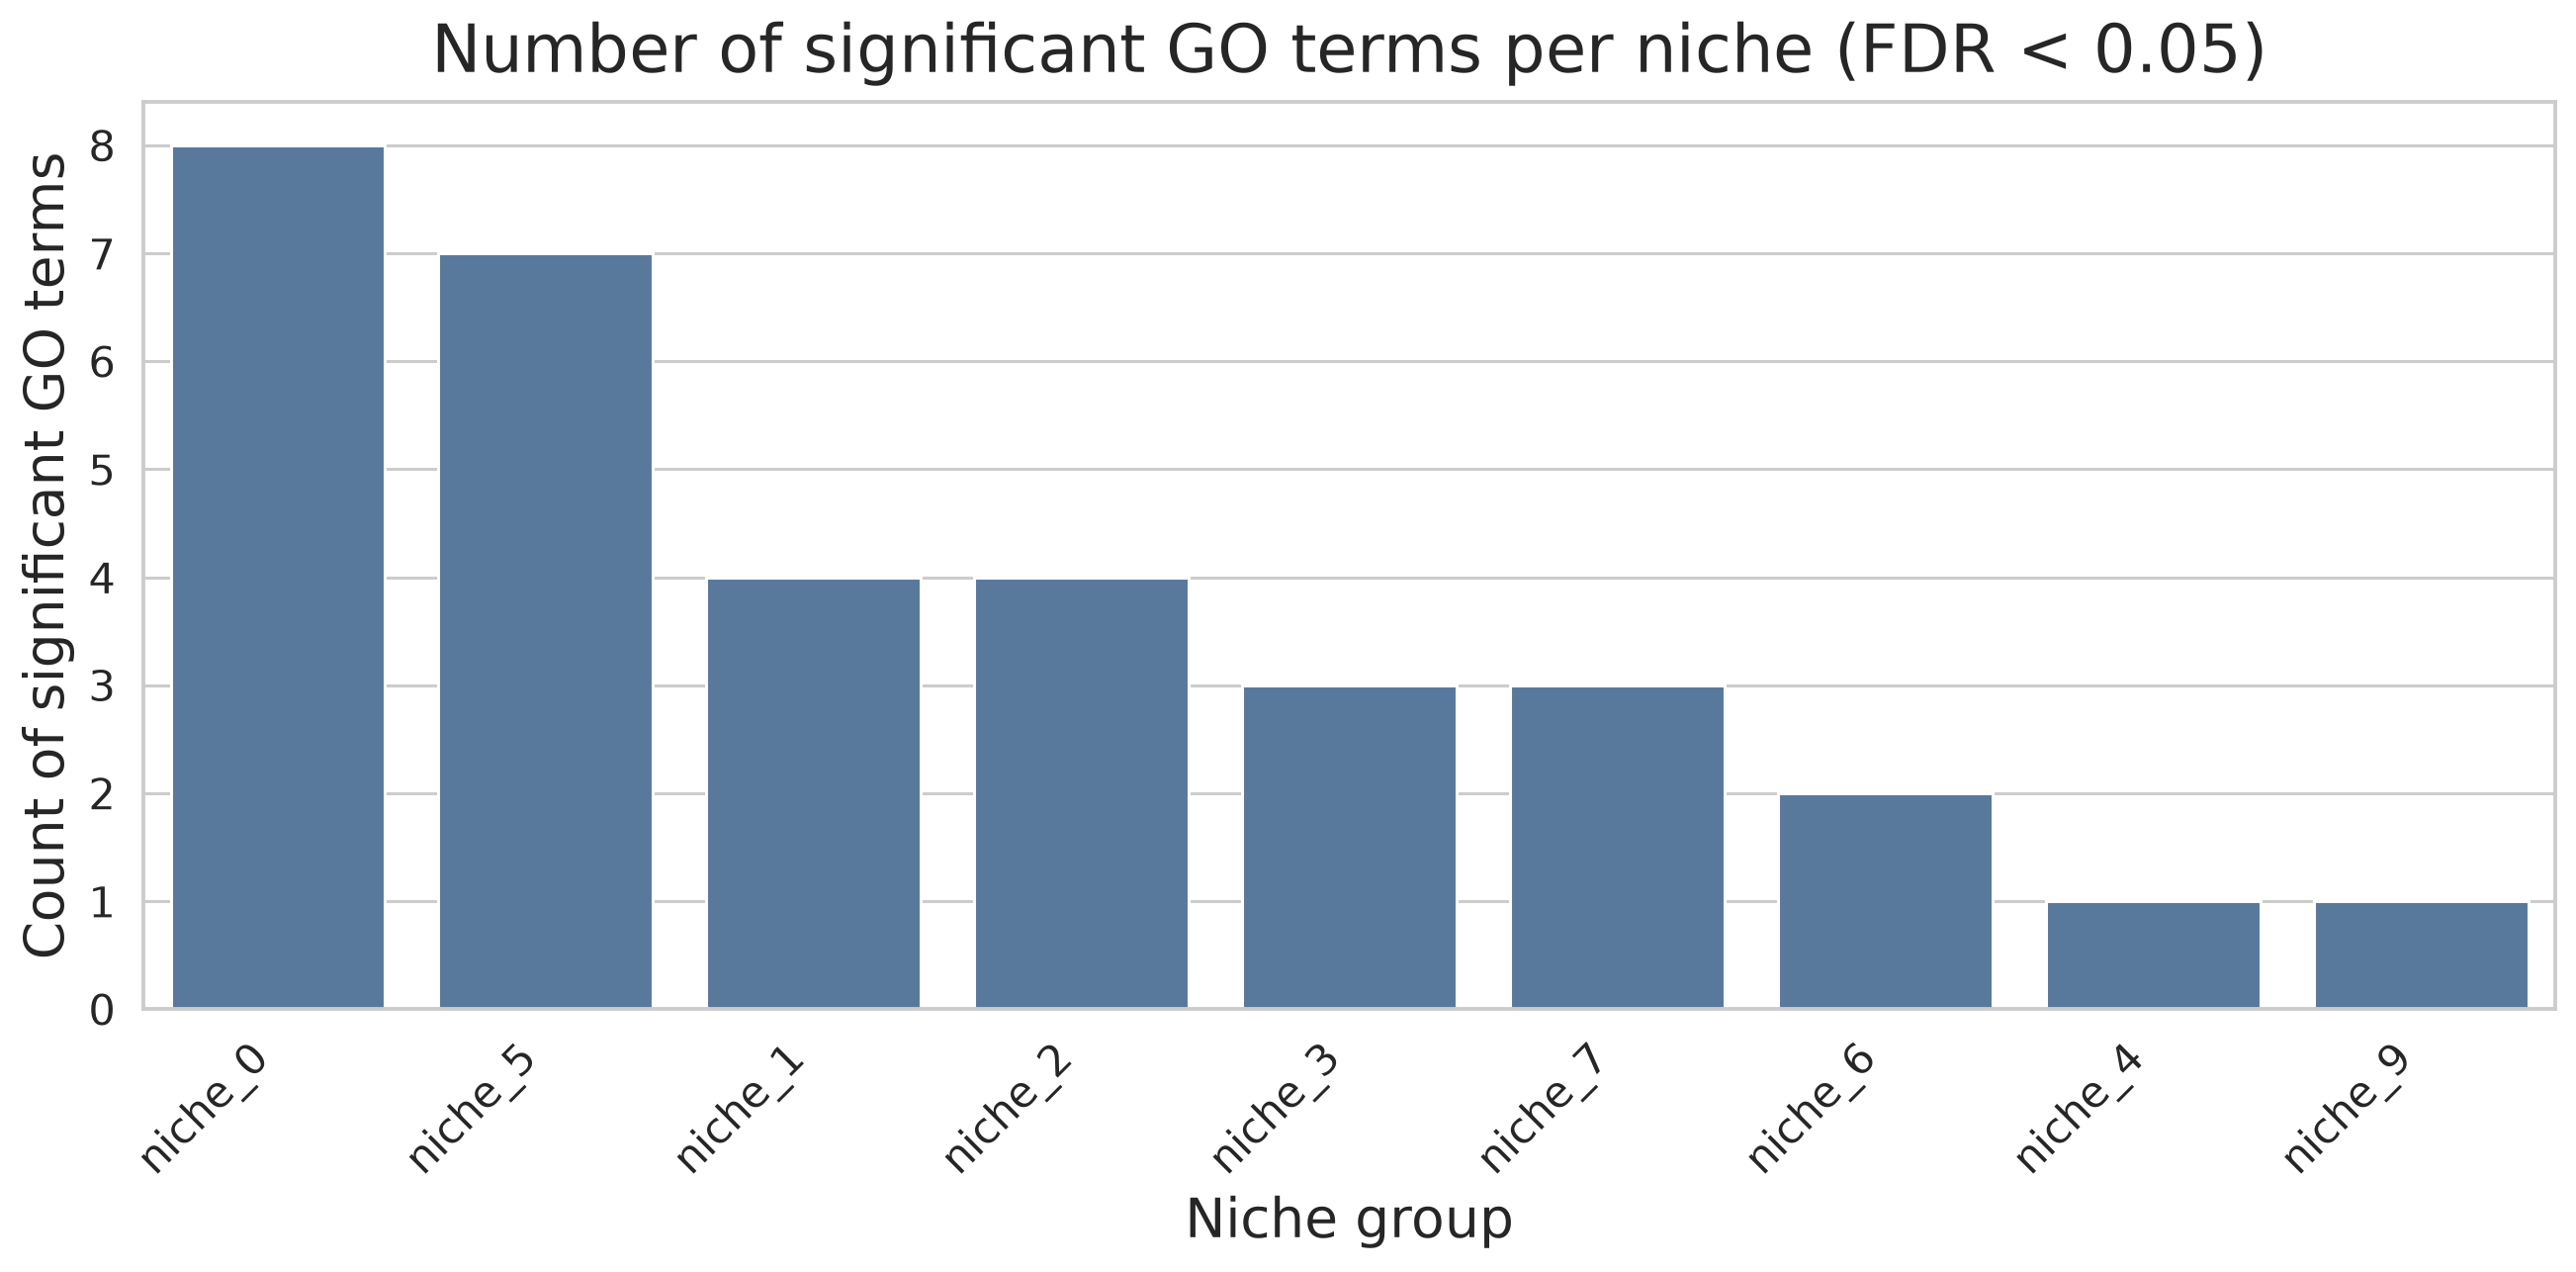

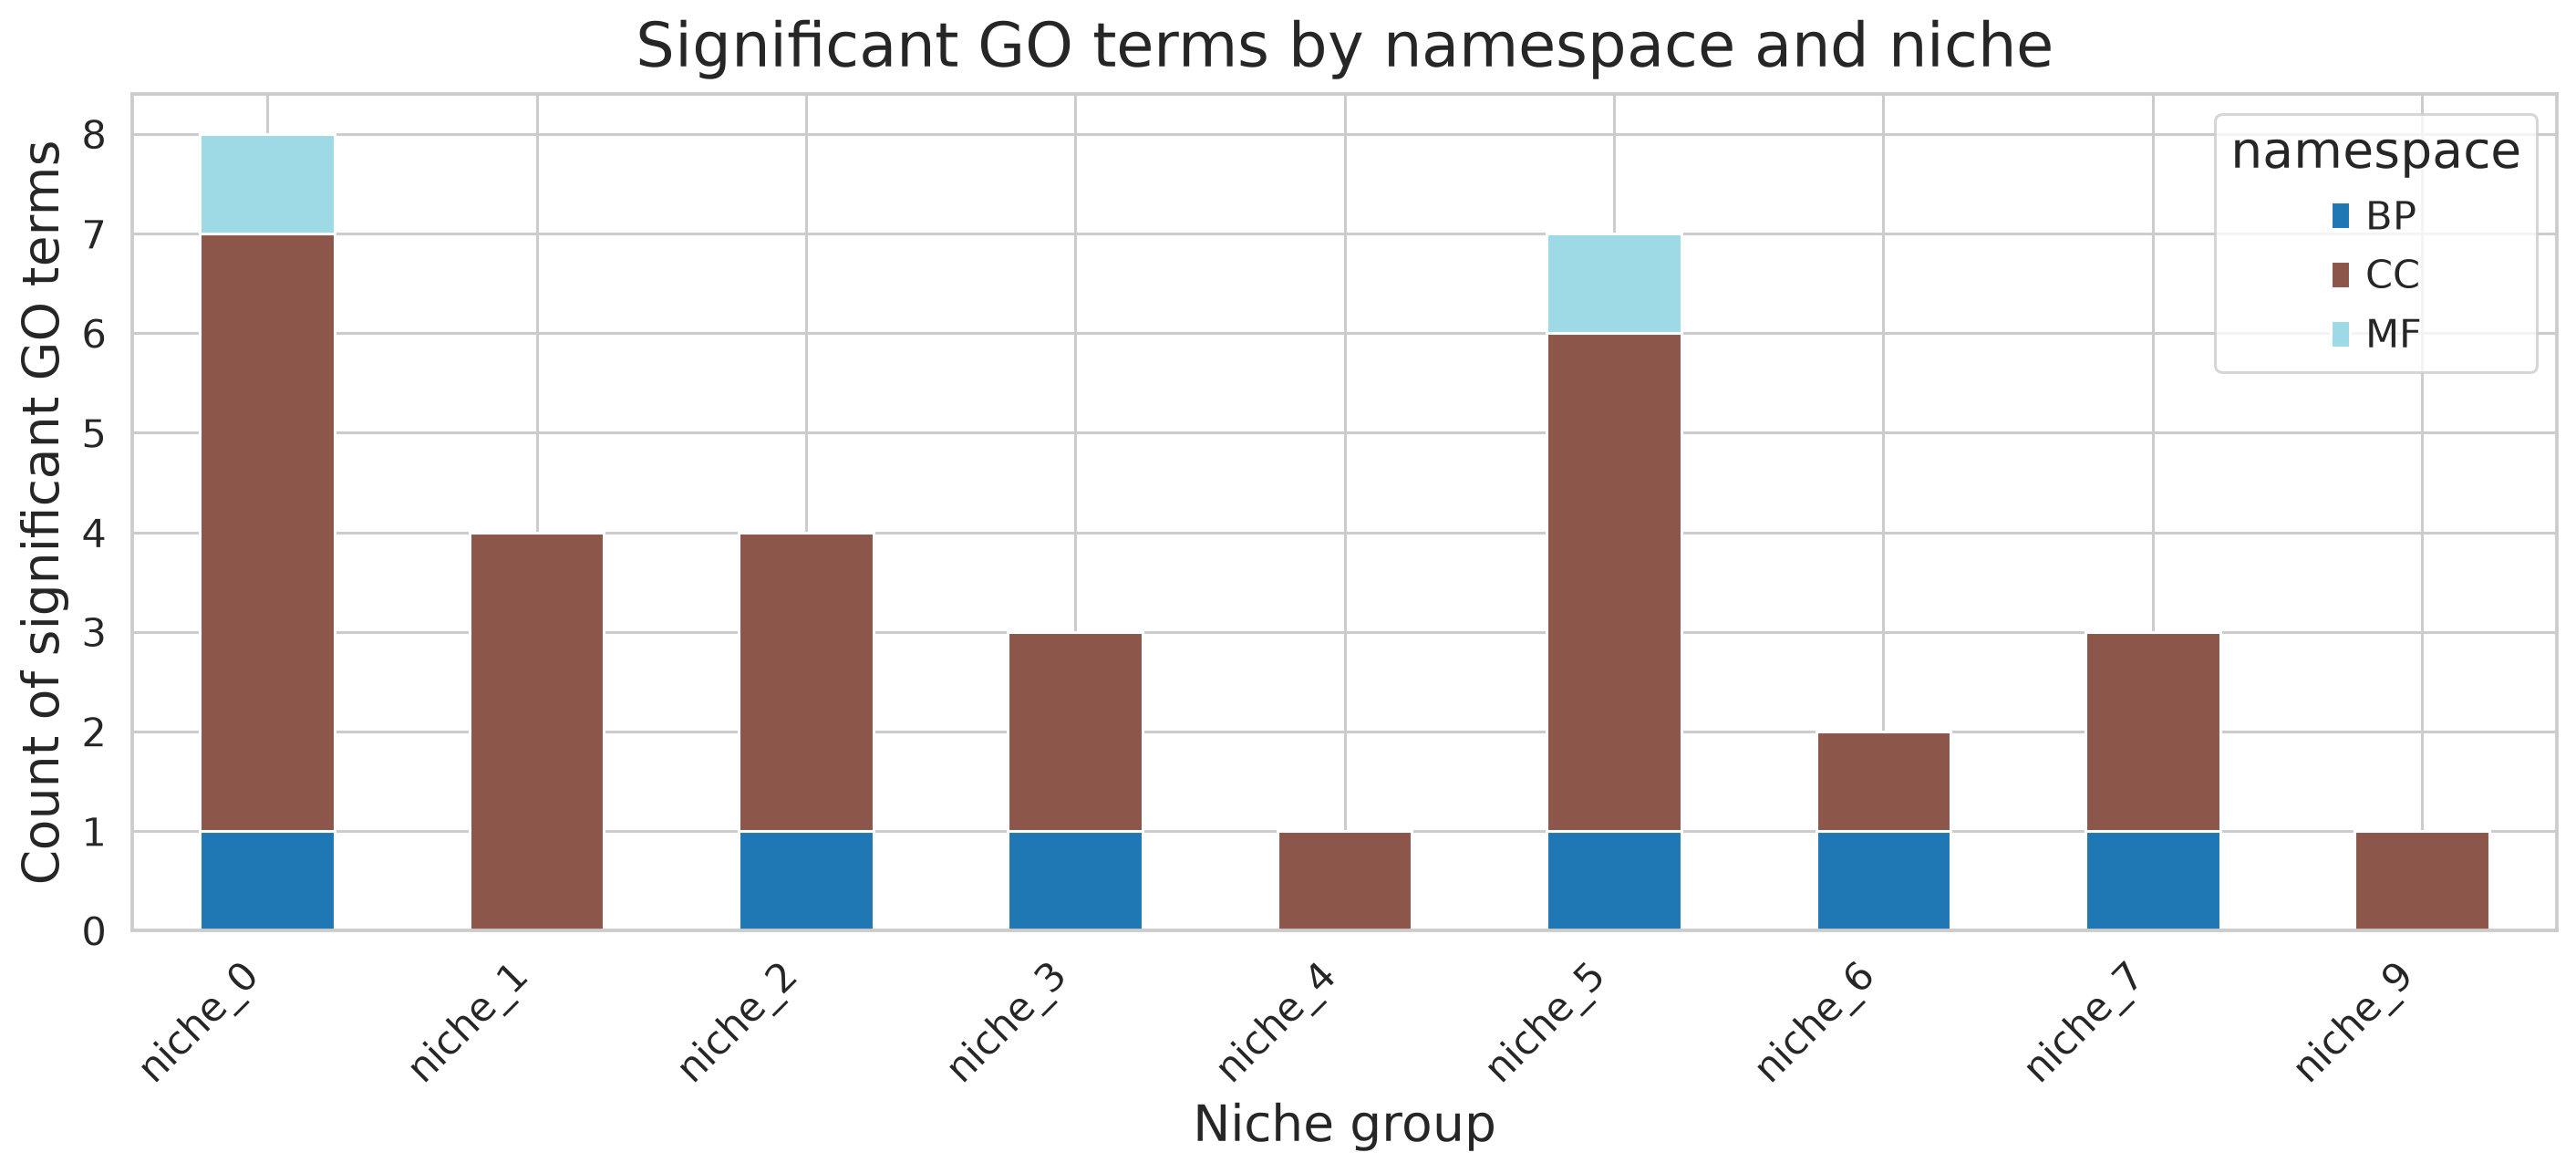

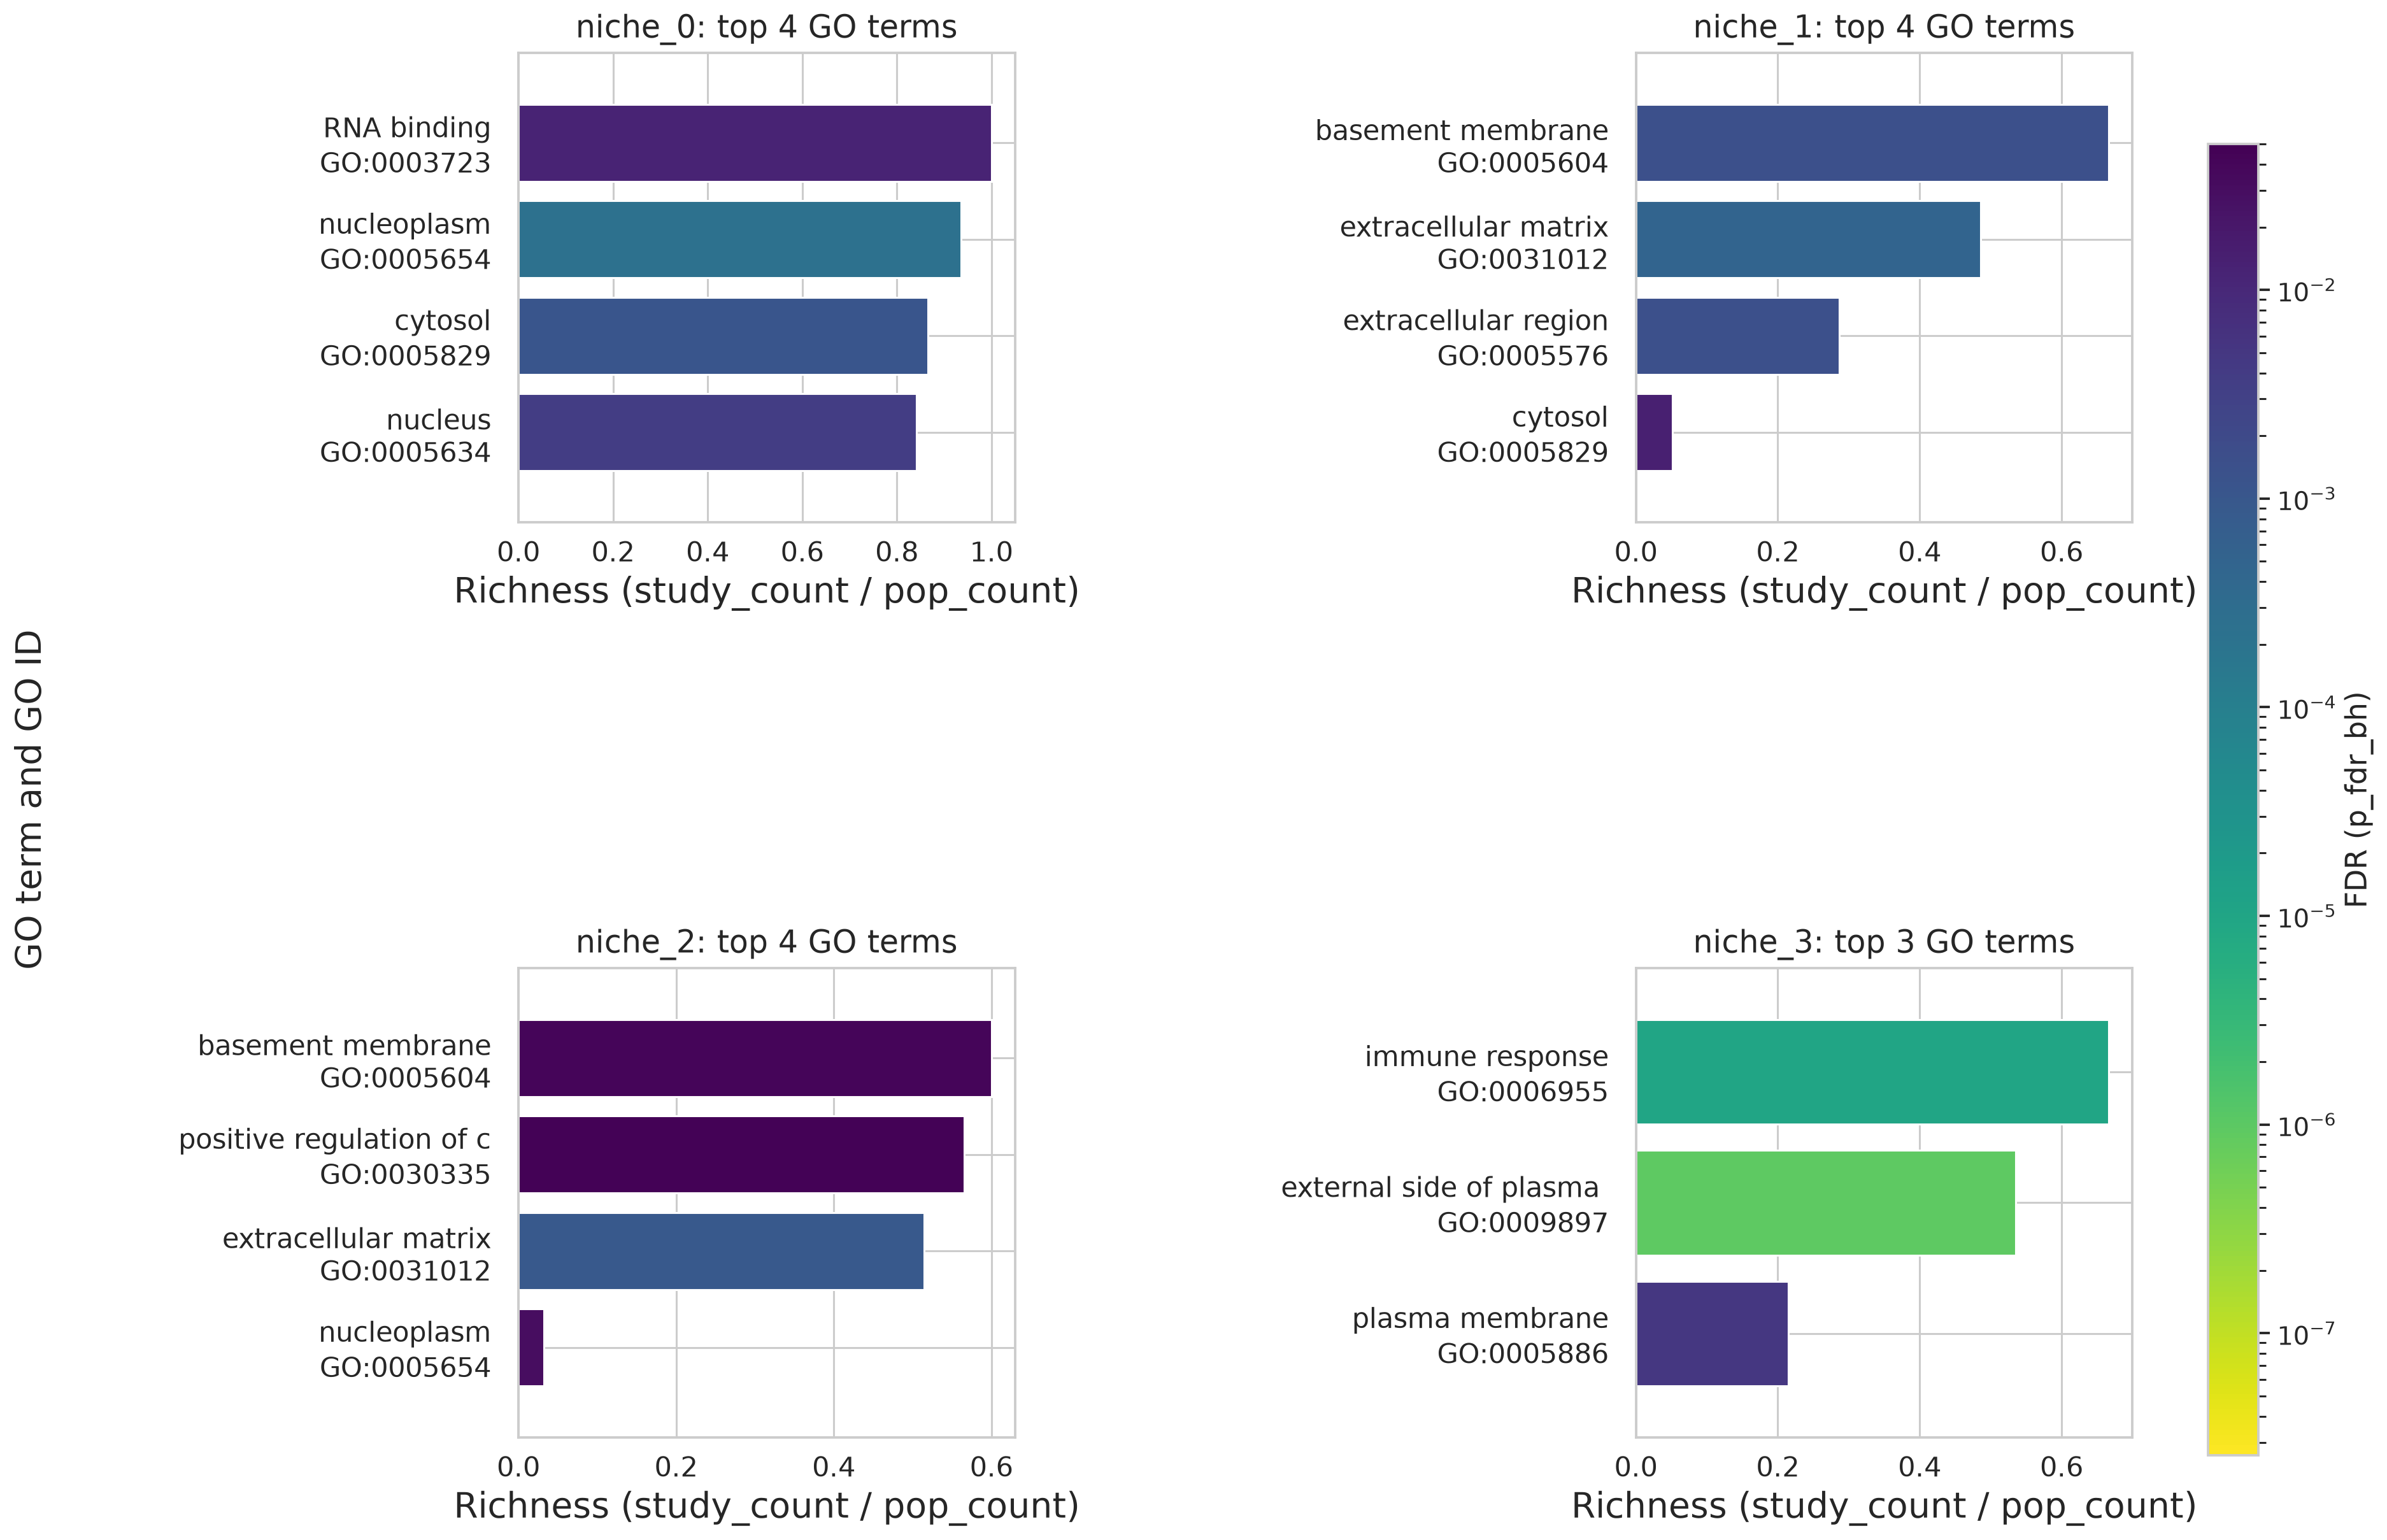

Saved figure: outputs/v3/goea_multi_niche/goea_sig_terms_richness_fdr_panels_page1.png


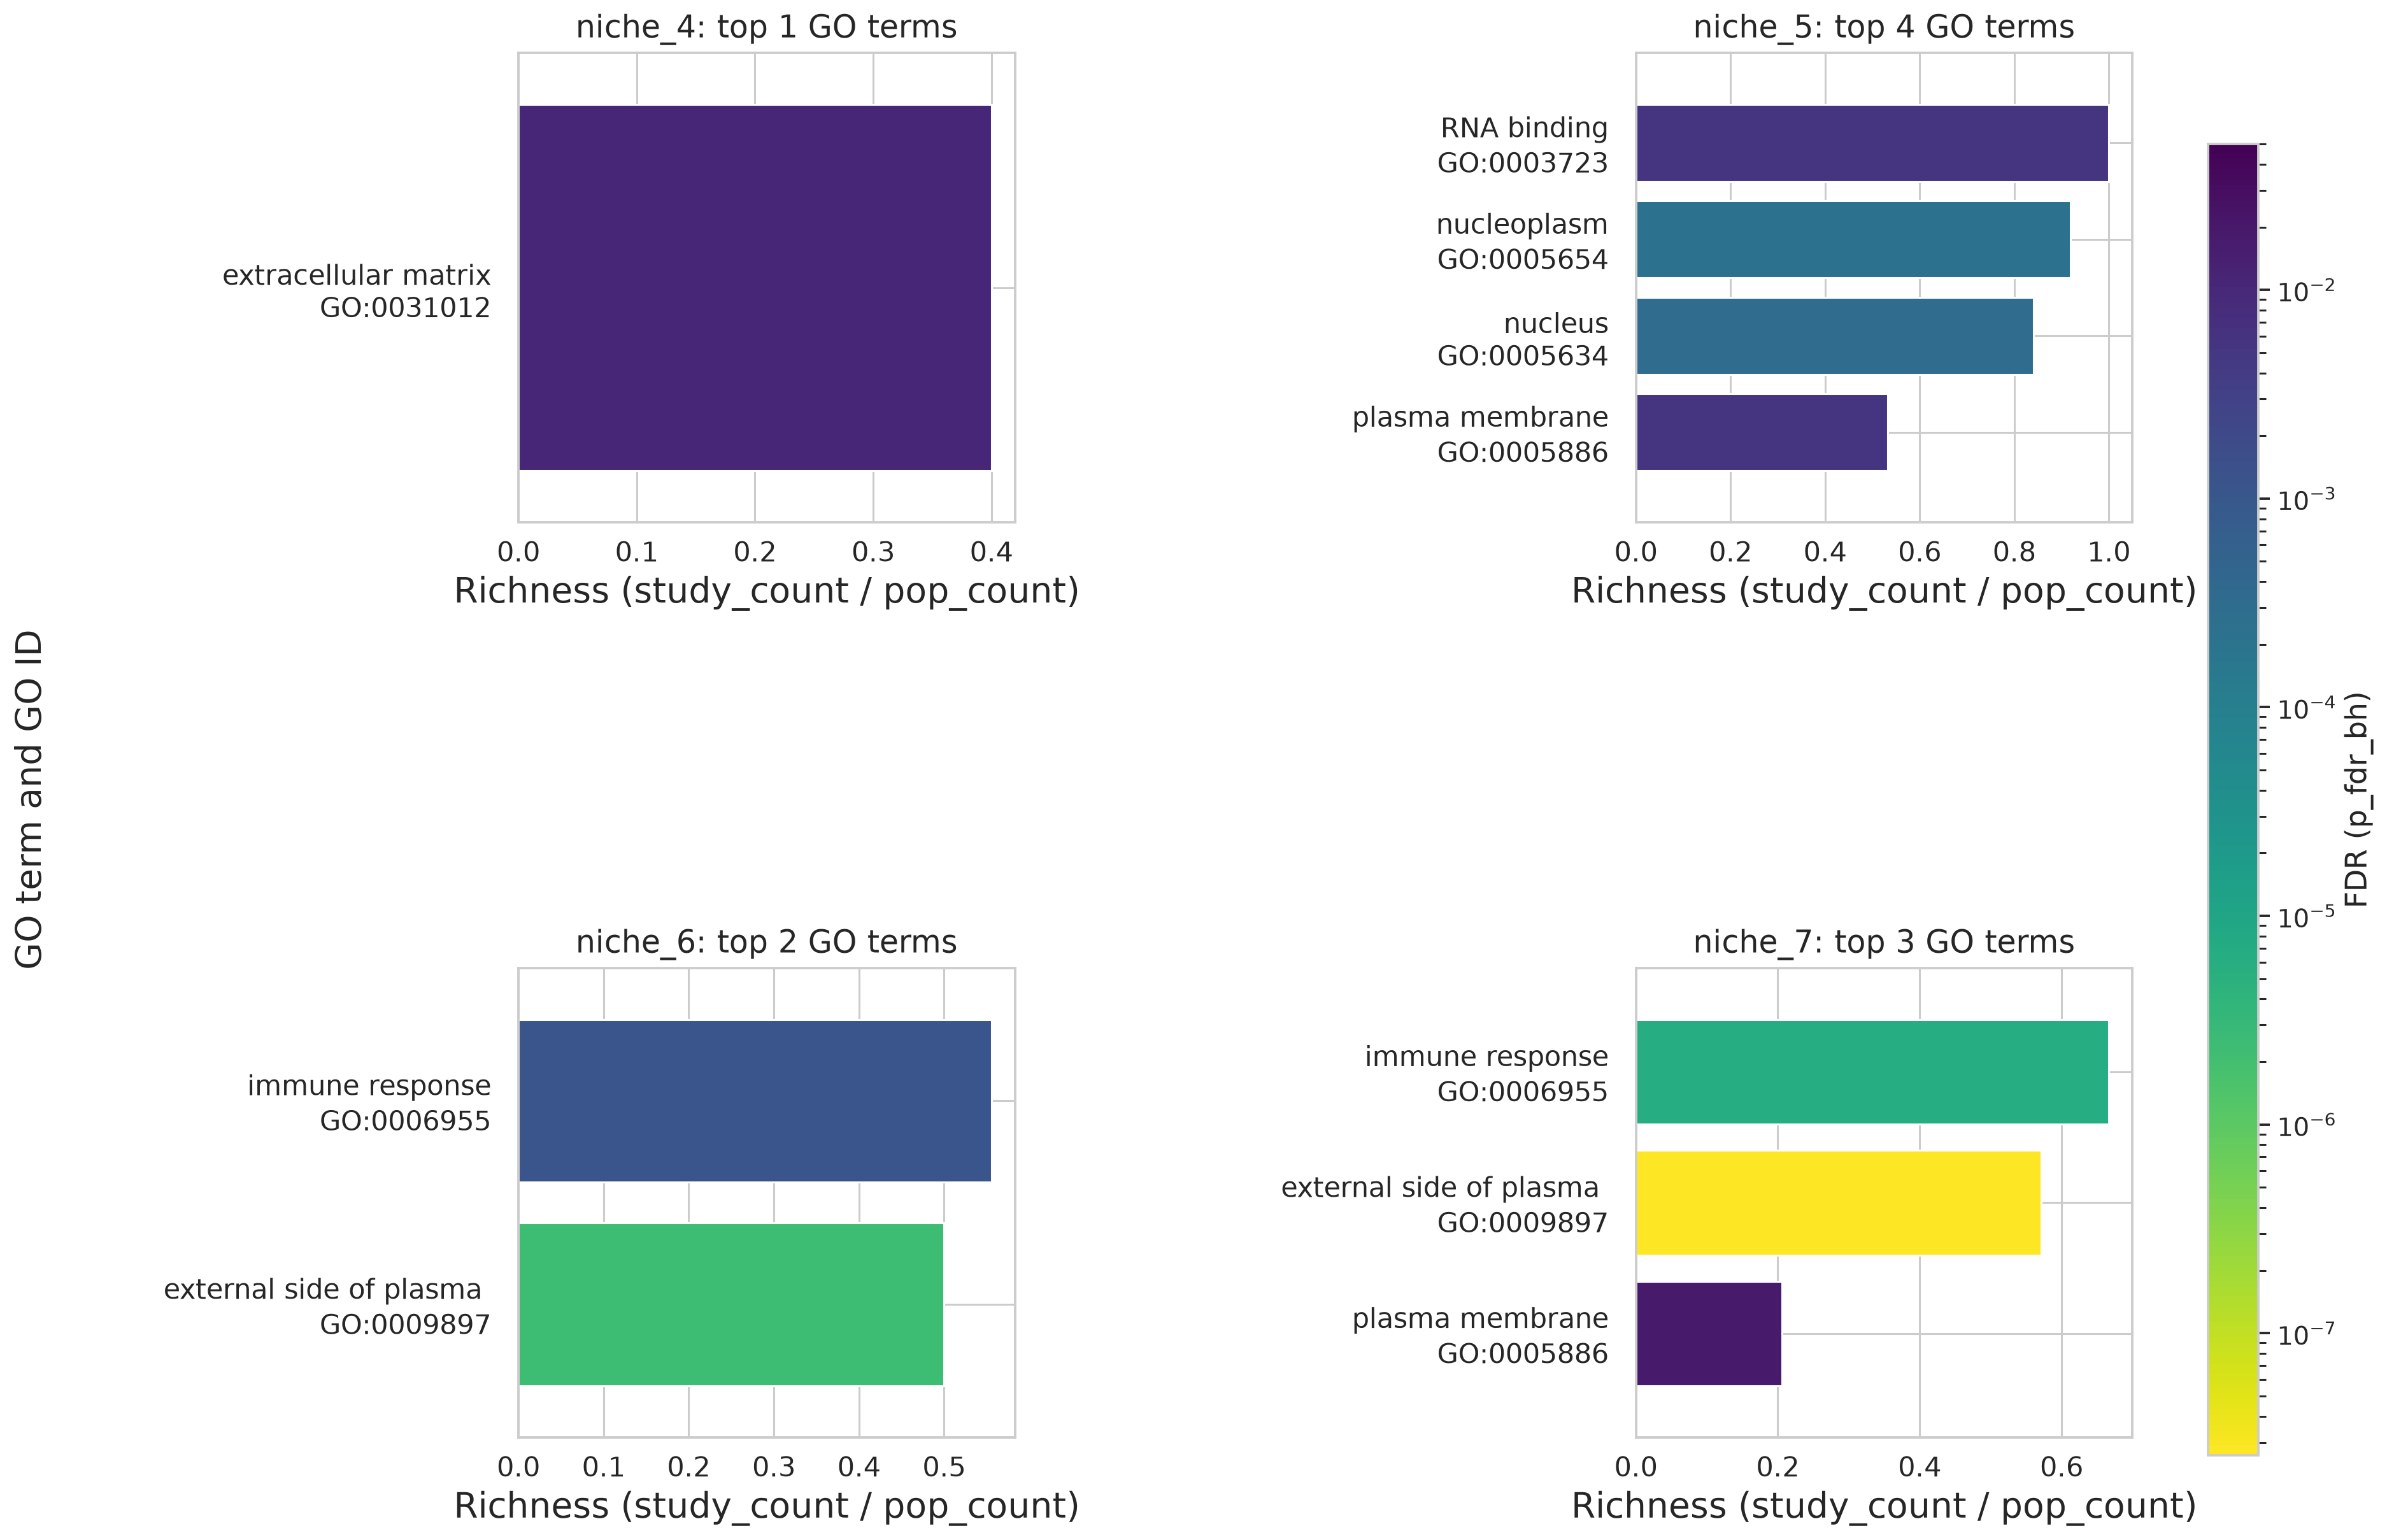

Saved figure: outputs/v3/goea_multi_niche/goea_sig_terms_richness_fdr_panels_page2.png


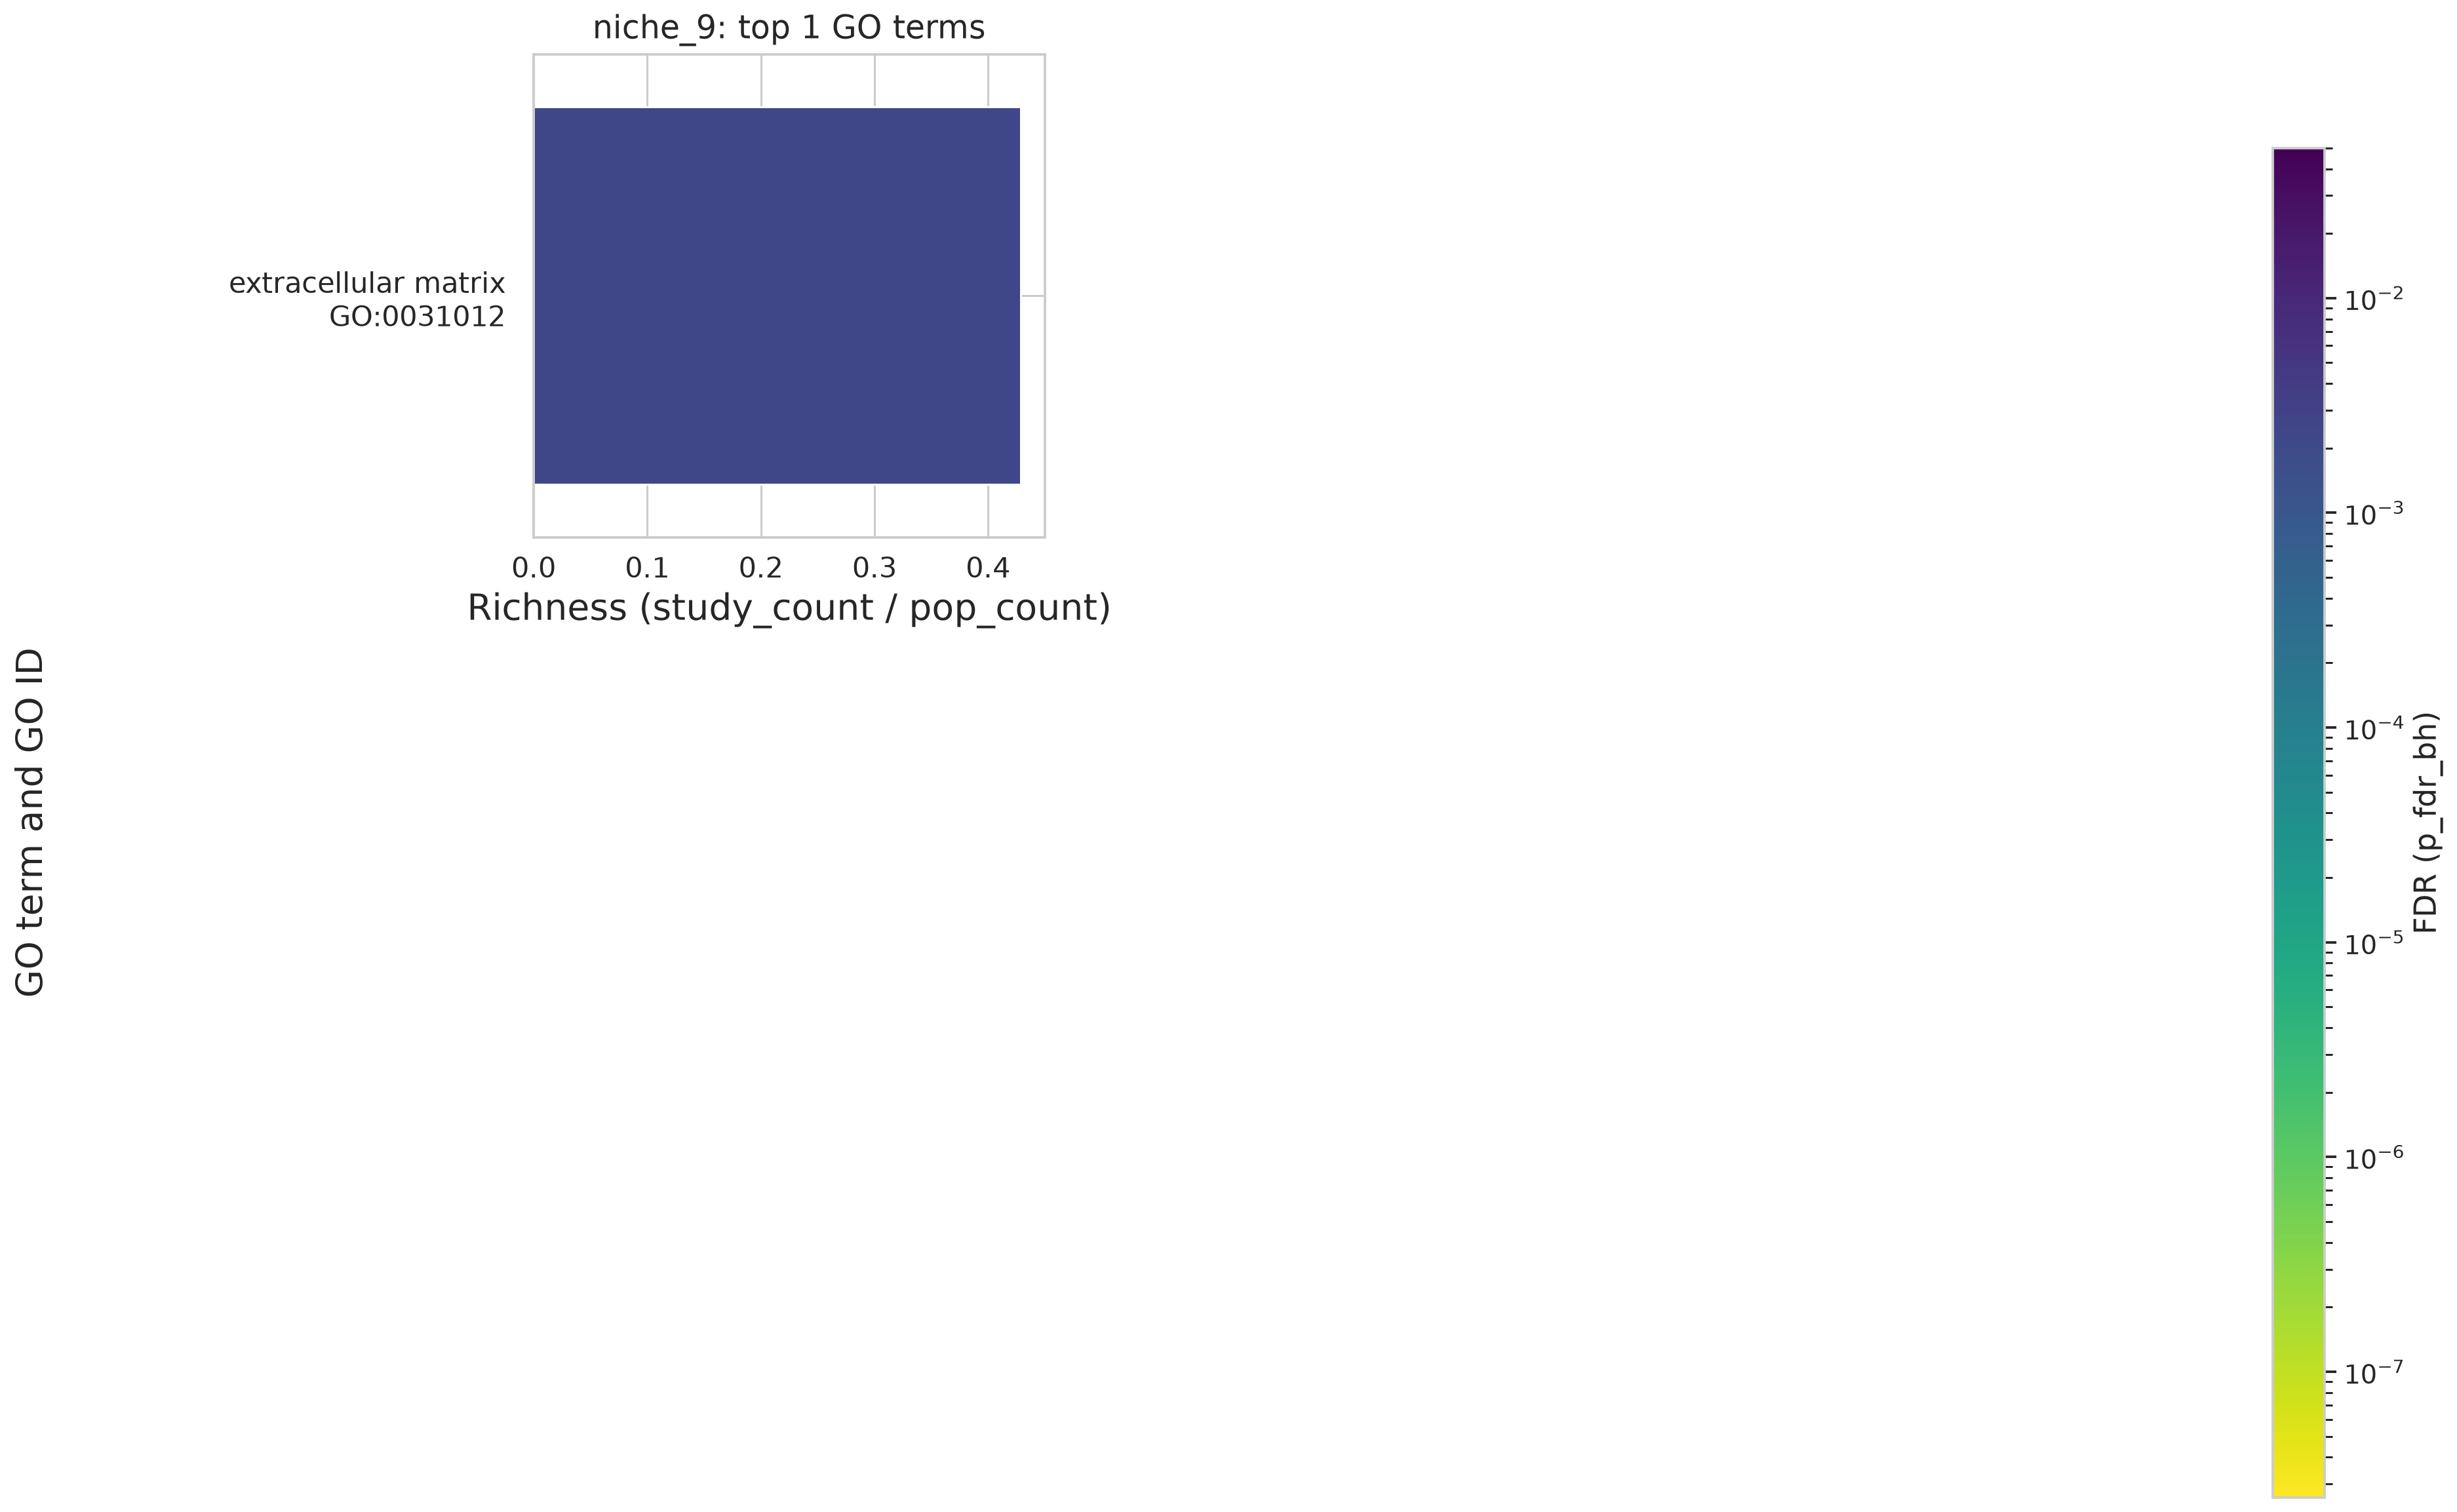

Saved figure: outputs/v3/goea_multi_niche/goea_sig_terms_richness_fdr_panels_page3.png
GOEA plots generated for niches: ['niche_0', 'niche_1', 'niche_2', 'niche_3', 'niche_4', 'niche_5', 'niche_6', 'niche_7', 'niche_9']
Saved plotting table: outputs/v3/goea_multi_niche/goea_sig_terms_plotting_table.csv
Saved figure: outputs/v3/goea_multi_niche/goea_sig_terms_count_per_niche.png
Saved figure: outputs/v3/goea_multi_niche/goea_sig_terms_namespace_stacked.png
Saved figure: outputs/v3/goea_multi_niche/goea_sig_terms_richness_fdr_panels.png


In [12]:
# GOEA visualization across all niches (beginner-friendly).
# This section creates plots for every niche group instead of showing only table text.

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import seaborn as sns

sns.set_theme(style="whitegrid")

paper_font = {
    "title": 22,
    "axis_label": 18,
    "tick": 14,
    "panel_title": 16,
    "cbar_label": 15,
    "cbar_tick": 13,
}

if goea_all.empty:
    print("Warning: goea_all is empty. Skipping GOEA plots in this run.")
else:
    # Keep only statistically significant terms for plotting.
    goea_sig_plot = goea_all.loc[goea_all["p_fdr_bh"] < 0.05].copy()
    if goea_sig_plot.empty:
        print("Warning: no significant GO terms (FDR < 0.05). Skipping GOEA plots.")
    else:
        goea_outdir = CFG["outdir"]
        goea_outdir.mkdir(parents=True, exist_ok=True)

        # Richness (a.k.a. RichFactor): fraction of GO-term background genes
        # recovered in the study set for that niche.
        goea_sig_plot["richness"] = (
            goea_sig_plot["study_count"] / goea_sig_plot["pop_count"].clip(lower=1)
        )

        # 1) Overview bar plot: how many significant GO terms per niche.
        terms_per_niche = (
            goea_sig_plot.groupby("niche_group", as_index=False)["GO"]
            .count()
            .rename(columns={"GO": "n_sig_terms"})
        )
        terms_per_niche = terms_per_niche.sort_values("n_sig_terms", ascending=False)

        fig1, ax1 = plt.subplots(figsize=(12, 6))
        sns.barplot(data=terms_per_niche, x="niche_group", y="n_sig_terms", color="#4C78A8", ax=ax1)
        ax1.set_title("Number of significant GO terms per niche (FDR < 0.05)", fontsize=paper_font["title"], pad=10)
        ax1.set_xlabel("Niche group", fontsize=paper_font["axis_label"])
        ax1.set_ylabel("Count of significant GO terms", fontsize=paper_font["axis_label"])
        ax1.tick_params(axis="x", rotation=45, labelsize=paper_font["tick"])
        ax1.tick_params(axis="y", labelsize=paper_font["tick"])
        for tick in ax1.get_xticklabels():
            tick.set_ha("right")
        fig1.tight_layout()
        fig1.savefig(goea_outdir / "goea_sig_terms_count_per_niche.png", dpi=300, bbox_inches="tight")
        plt.show()

        # 2) Stacked view by namespace (BP, CC, MF) per niche.
        ns_counts = (
            goea_sig_plot.groupby(["niche_group", "namespace"], as_index=False)["GO"]
            .count()
            .rename(columns={"GO": "n_terms"})
        )
        pivot_ns = ns_counts.pivot(index="niche_group", columns="namespace", values="n_terms").fillna(0)
        pivot_ns = pivot_ns.loc[sorted(pivot_ns.index)]

        ax2 = pivot_ns.plot(kind="bar", stacked=True, figsize=(13, 6), colormap="tab20")
        ax2.set_title("Significant GO terms by namespace and niche", fontsize=paper_font["title"], pad=10)
        ax2.set_xlabel("Niche group", fontsize=paper_font["axis_label"])
        ax2.set_ylabel("Count of significant GO terms", fontsize=paper_font["axis_label"])
        ax2.tick_params(axis="x", rotation=45, labelsize=paper_font["tick"])
        ax2.tick_params(axis="y", labelsize=paper_font["tick"])
        for tick in ax2.get_xticklabels():
            tick.set_ha("right")
        ax2.legend(title="namespace", fontsize=paper_font["tick"], title_fontsize=paper_font["axis_label"])
        fig2 = ax2.figure
        fig2.tight_layout()
        fig2.savefig(goea_outdir / "goea_sig_terms_namespace_stacked.png", dpi=300, bbox_inches="tight")
        plt.show()

        # 3) Per-niche panels: bar length = richness, bar color = FDR.
        # Publication layout: paginate into multiple figures so text remains readable on paper.
        niches_with_sig = sorted(goea_sig_plot["niche_group"].unique().tolist())
        top_n_terms = 4
        y_label_max_chars = 24

        # One page contains up to 4 niches (2x2).
        max_panels_per_page = 4
        n_cols = 2
        n_rows = 2

        cmap = plt.cm.viridis_r  # lower FDR is visually stronger
        norm = mcolors.LogNorm(
            vmin=max(float(goea_sig_plot["p_fdr_bh"].min()), 1e-300),
            vmax=0.05,
        )

        page_idx = 0
        for start in range(0, len(niches_with_sig), max_panels_per_page):
            page_idx += 1
            page_niches = niches_with_sig[start:start + max_panels_per_page]

            fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 13))
            axes = np.array(axes).reshape(-1)

            for i, niche in enumerate(page_niches):
                ax = axes[i]
                sub = goea_sig_plot.loc[goea_sig_plot["niche_group"] == niche].copy()
                sub = sub.sort_values(["richness", "p_fdr_bh"], ascending=[False, True]).head(top_n_terms)
                sub = sub.sort_values("richness", ascending=True)
                y_labels = [f"{n[:y_label_max_chars]}\n{g}" for g, n in zip(sub["GO"], sub["name"])]

                bar_colors = cmap(norm(sub["p_fdr_bh"].values))
                ax.barh(y_labels, sub["richness"], color=bar_colors)
                ax.set_title(f"{niche}: top {min(top_n_terms, len(sub))} GO terms", fontsize=paper_font["panel_title"], pad=8)
                ax.set_xlabel("Richness (study_count / pop_count)", fontsize=paper_font["axis_label"])
                ax.set_ylabel("")
                ax.tick_params(axis="x", labelsize=paper_font["tick"])
                ax.tick_params(axis="y", labelsize=paper_font["tick"], pad=8)
                for lbl in ax.get_yticklabels():
                    lbl.set_linespacing(1.2)
                ax.margins(y=0.14)

            # Hide unused panels on the last page.
            for j in range(len(page_niches), len(axes)):
                axes[j].axis("off")

            fig.text(0.02, 0.5, "GO term and GO ID", va="center", rotation=90, fontsize=paper_font["axis_label"])
            fig.subplots_adjust(left=0.22, right=0.86, hspace=0.95, wspace=1.25)

            sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
            sm.set_array([])
            cbar_ax = fig.add_axes([0.89, 0.14, 0.02, 0.72])
            cbar = fig.colorbar(sm, cax=cbar_ax)
            cbar.set_label("FDR (p_fdr_bh)", fontsize=paper_font["cbar_label"])
            cbar.ax.tick_params(labelsize=paper_font["cbar_tick"])

            page_path = goea_outdir / f"goea_sig_terms_richness_fdr_panels_page{page_idx}.png"
            fig.savefig(page_path, dpi=300, bbox_inches="tight")
            plt.show()
            print("Saved figure:", page_path)

        # Keep legacy single output name for backward compatibility (points to page 1 copy).
        legacy_path = goea_outdir / "goea_sig_terms_richness_fdr_panels.png"
        first_page_path = goea_outdir / "goea_sig_terms_richness_fdr_panels_page1.png"
        if first_page_path.exists():
            import shutil
            shutil.copy2(first_page_path, legacy_path)

        # Save plotting table for reproducibility.
        goea_sig_plot.to_csv(goea_outdir / "goea_sig_terms_plotting_table.csv", index=False)
        print("GOEA plots generated for niches:", niches_with_sig)
        print("Saved plotting table:", goea_outdir / "goea_sig_terms_plotting_table.csv")
        print("Saved figure:", goea_outdir / "goea_sig_terms_count_per_niche.png")
        print("Saved figure:", goea_outdir / "goea_sig_terms_namespace_stacked.png")
        print("Saved figure:", goea_outdir / "goea_sig_terms_richness_fdr_panels.png")

In [13]:
# Live OpenAI setup for niche labeling.
# Analogy: this is setting up a translator service that turns GO terms into short human-readable niche names.
# This cell loads API settings from .env and defines a helper function to request one label per niche.
from dotenv import find_dotenv, load_dotenv
from openai import OpenAI

client = None
model_name = "gpt-4.1-mini"
base_url = None

# Try to load .env; if unavailable, fall back to existing label CSV downstream.
dotenv_path = find_dotenv(".env", usecwd=True)
if not dotenv_path:
    print(f"Warning: .env not found from current working directory: {Path.cwd()}")
else:
    load_dotenv(dotenv_path=dotenv_path, override=True)
    api_key = (os.getenv("OPENAI_API_KEY") or "").strip()
    model_name = (os.getenv("OPENAI_MODEL") or "gpt-4.1-mini").strip()
    base_url = (os.getenv("OPENAI_BASE_URL") or "").strip() or None
    if base_url and not base_url.startswith(("http://", "https://")):
        # Ignore malformed custom URL to avoid client errors.
        base_url = None

    if api_key:
        client = OpenAI(api_key=api_key, base_url=base_url)
    else:
        print("Warning: OPENAI_API_KEY not found. Will fall back to cached label file if available.")


def ask_label(prompt_text):
    """Send one prompt and return one short clean label string."""
    if client is None:
        return "unknown niche"

    response = client.responses.create(
        model=model_name,
        input=(
            "You are a tumor microenvironment expert. "
            "Assign a conventional niche label used in pathology/immunology literature. "
            "The label must be specific enough to distinguish nearby niches in the same dataset. "
            "Avoid generic labels like immune niche or stromal niche unless no specific signal exists. "
            "Prefer biologically grounded wording with a clear modifier, such as immune interferon response niche or stromal collagen remodeling niche. "
            "Return exactly one lowercase label with 3-7 words, no punctuation, no explanation.\n\n"
            + prompt_text
        ),
    )
    out = (getattr(response, "output_text", "") or "").strip()
    if not out:
        return "unknown niche"
    # Keep first line and strip quotes for cleaner downstream CSV values.
    return out.splitlines()[0].strip().strip('"').strip("'").lower()

print("OpenAI client ready:", client is not None)
print("Model:", model_name)
print("Using custom base URL:", bool(base_url))

OpenAI client ready: True
Model: gpt-4.1-mini
Using custom base URL: False


### OpenAI Client Ready
What you should see: confirmation that the client is ready, selected model name, and whether a custom base URL is used.

Generated files: none.

Important carry-forward variables/functions:
- `client`: authenticated OpenAI client.
- `ask_label(prompt_text)`: returns one niche subtype label from GO-term context.
- `model_name`: recorded model identifier for provenance.

Next step: run niche-wise prompt labeling and save `niche_labels_by_niche.csv`.

In [14]:
# Build prompts from significant GO terms and request one niche label per niche group.
# Analogy: this is giving key bullet points to an expert and asking for a short diagnosis label.
import re

prompt_top_n = 8  # Number of top GO terms included in each prompt.
label_rows = []
used_labels = set()

# Fallback 1: if no significant GO terms, try to reuse an existing label table.
if goea_sig.empty:
    existing_label_csv = CFG["outdir"] / "niche_labels_by_niche.csv"
    if existing_label_csv.exists():
        niche_labels_df = pd.read_csv(existing_label_csv).sort_values("niche_group").reset_index(drop=True)
        print("No significant GO terms in this run. Reused existing labels from:", existing_label_csv)
        print(niche_labels_df[["niche_group", "niche_label"]].to_string(index=False))
    else:
        # Fallback 2: deterministic placeholder labels so downstream cells still run.
        niche_labels_df = pd.DataFrame(
            {
                "niche_group": niche_list,
                "niche_label": [f"label_{g}" for g in niche_list],
                "top_go_terms": "",
                "niche_prompt": "",
            }
        )
        niche_labels_df.to_csv(existing_label_csv, index=False)
        print("No GOEA terms and no cached labels. Created placeholder labels at:", existing_label_csv)
else:
    for niche_col in niche_list:
        # Keep only significant terms for this niche group.
        niche_sig = goea_sig.loc[goea_sig["niche_group"] == niche_col].copy()
        if niche_sig.empty:
            continue

        # Select most significant terms (smallest FDR q-value).
        top_terms = niche_sig.nsmallest(prompt_top_n, "p_fdr_bh").copy()
        top_terms["term_text"] = top_terms["GO"] + " | " + top_terms["name"] + " (" + top_terms["namespace"] + ")"
        top_go_terms = "; ".join(top_terms["term_text"].tolist())

        # Candidate qualifier words for duplicate fallback.
        qualifier_tokens = []
        for term_name in top_terms["name"].astype(str).tolist():
            words = re.findall(r"[a-z]+", term_name.lower())
            for w in words:
                if w not in {"process", "regulation", "positive", "negative", "cell", "cells", "response", "pathway"} and len(w) >= 4:
                    qualifier_tokens.append(w)
        fallback_qualifier = qualifier_tokens[0] if qualifier_tokens else niche_col.replace("_", "")

        # Compose a stronger prompt to favor conventional but distinguishable niche names.
        prompt_text = (
            f"Niche group ID: {niche_col}. "
            f"Top enriched GO terms: {top_go_terms}. "
            f"Labels already assigned to other niches: {sorted(used_labels) if used_labels else 'none yet'}. "
            "Task: map this biology to one conventional tumor-microenvironment niche name used in published pathology/immunology studies. "
            "Choose the most specific conventional name possible and avoid reusing an existing label unless the biology is truly identical. "
            "Use a clear biological modifier (for example interferon, antigen presentation, collagen remodeling, angiogenic, proliferative, hypoxic, lymphoid, myeloid). "
            "Return one short label only."
        )

        niche_label = ask_label(prompt_text)
        niche_label = re.sub(r"[^a-z0-9 ]+", " ", str(niche_label).lower())
        niche_label = " ".join(niche_label.split())

        # One retry if the label duplicates an already used one.
        if niche_label in used_labels:
            retry_prompt = (
                prompt_text
                + f" The label {niche_label} is already used. Choose a different but still conventional and biologically specific label for this niche. Return one label only."
            )
            niche_label = ask_label(retry_prompt)
            niche_label = re.sub(r"[^a-z0-9 ]+", " ", str(niche_label).lower())
            niche_label = " ".join(niche_label.split())

        # Final deterministic disambiguation if still duplicated.
        if niche_label in used_labels:
            niche_label = f"{niche_label} {fallback_qualifier}".strip()
            niche_label = re.sub(r"[^a-z0-9 ]+", " ", niche_label)
            niche_label = " ".join(niche_label.split())

        used_labels.add(niche_label)
        label_rows.append(
            {
                "niche_group": niche_col,
                "niche_label": niche_label,
                "top_go_terms": top_go_terms,
                "niche_prompt": prompt_text,
            }
        )

    # Save label table used by Stage 3 supervised learning.
    niche_labels_df = pd.DataFrame(label_rows)
    if niche_labels_df.empty:
        # If GOEA existed but no niches were labelable, keep pipeline moving.
        niche_labels_df = pd.DataFrame(
            {
                "niche_group": niche_list,
                "niche_label": [f"label_{g}" for g in niche_list],
                "top_go_terms": "",
                "niche_prompt": "",
            }
        )
    niche_labels_df = niche_labels_df.sort_values("niche_group").reset_index(drop=True)
    niche_labels_df.to_csv(CFG["outdir"] / "niche_labels_by_niche.csv", index=False)

print(f"Labeled niche groups: {len(niche_labels_df)}")
print(niche_labels_df[["niche_group", "niche_label"]].to_string(index=False))

Labeled niche groups: 9
niche_group                                     niche_label
    niche_0               immune antigen presentation niche
    niche_1                 stromal basement membrane niche
    niche_2   stromal extracellular matrix remodeling niche
    niche_3         immune plasma membrane activation niche
    niche_4 stromal extracellular matrix organization niche
    niche_5   immune extracellular matrix interaction niche
    niche_6          immune plasma membrane signaling niche
    niche_7           immune plasma membrane receptor niche
    niche_9   stromal extracellular matrix deposition niche


### Niche Labels Generated
What you should see: number of labeled niche groups and a table mapping each group to a niche label.

Generated files:
- `outputs/v*/goea_multi_niche/niche_labels_by_niche.csv`

Important carry-forward variables:
- `niche_labels_df`: key supervision table used in vector labeling and supervised dataset construction.

### Next Computation: Build Niche Summary Vectors
For each niche group $i$ with feature dimension $d$, the next step builds:
$$
z_i=[\mu_{i,1},\dots,\mu_{i,d},\sigma_{i,1},\dots,\sigma_{i,d}]\in\mathbb{R}^{2d},
$$

In [15]:
# Build one vector per niche group using mean and standard deviation of feature columns.
# Analogy: this is summarizing each class by its average profile plus how much it varies.
# Final vector format per niche: [means..., stds...].
obs = adata_work.obs.copy()
niche_group_cols = niche_list
niche_feature_cols = feature_cols

# Convert to numeric to avoid issues if values are strings/mixed types.
obs_niche = obs[niche_group_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
obs_feat = obs[niche_feature_cols].apply(pd.to_numeric, errors="coerce")

vector_rows = []
for niche_col in niche_group_cols:
    # Select cells belonging to this niche group.
    niche_mask = obs_niche[niche_col] == 1
    n_cells = int(niche_mask.sum())
    if n_cells == 0:
        continue

    # Compute per-feature mean and std for this niche.
    niche_feat = obs_feat.loc[niche_mask, niche_feature_cols]
    mean_vec = niche_feat.mean(axis=0, skipna=True).to_numpy()
    std_vec = niche_feat.std(axis=0, ddof=1, skipna=True).to_numpy()
    concat_vec = np.concatenate([mean_vec, std_vec])

    vector_rows.append({
        "niche_group": niche_col,
        "n_cells": n_cells,
        "feature_count": len(niche_feature_cols),
        "vector_length": int(concat_vec.shape[0]),
        "concat_mean_std_vector": concat_vec.tolist(),
    })

if not vector_rows:
    raise RuntimeError("No niche group had member cells.")

# Table form for easy saving/inspection.
niche_concat_vectors_df = pd.DataFrame(vector_rows).sort_values("niche_group").reset_index(drop=True)
if "niche_labels_df" in globals() and not niche_labels_df.empty:
    # Attach human-readable niche labels when available.
    niche_concat_vectors_df = niche_concat_vectors_df.merge(
        niche_labels_df[["niche_group", "niche_label"]],
        on="niche_group",
        how="left",
    )

# Save both long-table and matrix versions of vectors.
niche_concat_vectors_df.to_csv(CFG["outdir"] / "niche_feature_concat_mean_std_vector_by_niche.csv", index=False)
vector_matrix = pd.DataFrame(niche_concat_vectors_df["concat_mean_std_vector"].tolist(), index=niche_concat_vectors_df["niche_group"])
vector_matrix.columns = [f"v_{i}" for i in range(vector_matrix.shape[1])]
vector_matrix.to_csv(CFG["outdir"] / "niche_feature_concat_mean_std_vector_matrix_by_niche.csv")

print("Niche groups summarized:", niche_concat_vectors_df["niche_group"].nunique())
print("Feature dim:", len(niche_feature_cols))
print("Vector length:", 2 * len(niche_feature_cols))

Niche groups summarized: 10
Feature dim: 18
Vector length: 36


**Niche Summary Vectors**
What you should see: number of summarized niche groups, feature dimension, and final vector length.

Generated files:
- `outputs/v*/goea_multi_niche/niche_feature_concat_mean_std_vector_by_niche.csv`
- `outputs/v*/goea_multi_niche/niche_feature_concat_mean_std_vector_matrix_by_niche.csv`

Important carry-forward variables:
- `niche_concat_vectors_df`: cohort-level per-group vectors with optional labels.
- `vector_matrix`: tabular vector matrix.
- `obs_niche`, `obs_feat`: processed subsets used to build vectors.

Split note: Stage 3 then rebuilds per-sample vectors from the same 12-sample cohort to enforce training on 6 samples and held-out validation/testing on 6 samples.

## Stage 3: Sample-Level Supervised Modeling and Validation

In this stage, we use the labels from Stage 2 to train a neural network that predicts niche labels from H&E-derived vectors.

High-school flow:
1. Build one numeric vector for each niche group in each sample.
2. Split samples into two groups: 6 training samples and 6 held-out samples.
3. Train the model on training samples only.
4. Test on held-out samples to measure how well the model generalizes to unseen data.

Important idea:
- Training data is for learning.
- Held-out data is for fair testing.
- We never let the model see held-out answers during training.

In [16]:
import ast
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import TensorDataset

# Resolve the sample-split output directory from central configuration.
sample_split_dir = Path(CFG["sample_split_dir"])


def _parse_vector(x):
    if isinstance(x, str):
        text = x.strip()
        if not text:
            return []
        if text.startswith("[") and text.endswith("]"):
            try:
                return json.loads(text.replace("'", '"'))
            except Exception:
                pass
            try:
                return [float(tok) for tok in text[1:-1].split() if tok]
            except Exception:
                return []
        try:
            return ast.literal_eval(text)
        except Exception:
            return []
    return x


def _load_vector_table(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "vector" in df.columns:
        df["vector"] = df["vector"].apply(_parse_vector)
    return df

print("Stage 3 helpers ready.")
print("Using sample split directory:", sample_split_dir)

Stage 3 helpers ready.
Using sample split directory: outputs/v3/nn_sample_split


### Load and Split the Master Vector Table
This cell rebuilds the sample-level training and held-out tables from `all_vectors.csv`, which is the source of truth for all 12 samples.

High-school explanation:
- Think of each sample as one student report card with many numbers.
- We are splitting report cards into two piles:
  - training pile: the model is allowed to learn from these.
  - held-out pile: the model is tested on these later.

Why we do this split:
- If we test on the same data we trained on, the score can look unrealistically good.
- Held-out testing is like giving a new exam the model has not seen before.

What this cell guarantees:
1. Rebuilds the master table if old cache is stale.
2. Creates clean train and test tables using the fixed sample split.
3. Saves coverage summaries so you can see what was included/excluded.

Vocabulary:
- `row`: one niche-vector example.
- `label`: the target class name we want to predict.
- `split`: whether a row belongs to training or held-out testing.

In [17]:
# Rebuild the sample-level vector tables from the master table.
# Analogy: this is like returning to the full workbook and then making a clean 6/6 split from the sample IDs.

master_vectors_path = sample_split_dir / "all_vectors.csv"

def _build_master_vectors_from_obs():
    """Build master vectors from current AnnData + current niche list."""
    required_globals = ["adata_work", "niche_list", "feature_cols", "CFG"]
    missing_globals = [g for g in required_globals if g not in globals()]
    if missing_globals:
        raise RuntimeError(
            "Missing prerequisites to build all_vectors.csv: "
            f"{missing_globals}. Run the earlier Stage 0-2 cells first."
        )

    # Prefer in-memory labels, then on-disk labels; final fallback is using niche IDs as labels.
    if "niche_labels_df" in globals() and isinstance(niche_labels_df, pd.DataFrame) and not niche_labels_df.empty:
        labels_df = niche_labels_df.copy()
    else:
        label_csv = Path(CFG["outdir"]) / "niche_labels_by_niche.csv"
        if label_csv.exists():
            labels_df = pd.read_csv(label_csv)
            print("Loaded niche labels from:", label_csv)
        else:
            labels_df = pd.DataFrame({"niche_group": niche_list, "niche_label": niche_list})
            print(
                "Warning: no niche label CSV found. "
                "Using niche IDs as temporary labels."
            )

    obs = adata_work.obs.copy()
    label_map = dict(zip(labels_df["niche_group"], labels_df["niche_label"]))
    vector_rows = []

    for sample_id in CFG["all_sample_stems"]:
        sample_obs = obs.loc[obs["sample_id"] == sample_id].copy()
        if sample_obs.empty:
            continue

        split_name = "train" if sample_id in CFG["train_sample_stems"] else "test"

        for niche_col in niche_list:
            if niche_col not in label_map:
                continue

            membership = pd.to_numeric(sample_obs[niche_col], errors="coerce").fillna(0).astype(int)
            mask = membership.eq(1)
            n_cells = int(mask.sum())
            if n_cells == 0:
                continue

            feat = sample_obs.loc[mask, feature_cols].apply(pd.to_numeric, errors="coerce")
            mean_vec = feat.mean(axis=0, skipna=True).to_numpy(dtype=float)
            std_vec = feat.std(axis=0, ddof=1, skipna=True).to_numpy(dtype=float)
            vec = np.concatenate([mean_vec, std_vec]).astype(float).tolist()

            vector_rows.append(
                {
                    "sample_id": sample_id,
                    "niche_group": niche_col,
                    "niche_label": label_map[niche_col],
                    "n_cells": n_cells,
                    "vector": vec,
                    "source": "base",
                    "split": split_name,
                }
            )

    built_df = pd.DataFrame(vector_rows)
    if built_df.empty:
        raise RuntimeError(
            "Failed to build all_vectors.csv from in-memory data. "
            "Check that niche membership columns, feature columns, and niche labels are available."
        )
    return built_df

# Load cached table if available, but auto-rebuild when schema or niche-group set is stale.
rebuild_reason = None
if master_vectors_path.exists():
    dataset_df = _load_vector_table(master_vectors_path)

    if "niche_group" not in dataset_df.columns:
        rebuild_reason = "missing niche_group column"
    elif "niche_list" in globals():
        cached_groups = set(dataset_df["niche_group"].dropna().astype(str).unique().tolist())
        current_groups = set([str(x) for x in niche_list])
        if cached_groups != current_groups:
            rebuild_reason = (
                f"niche groups changed (cached={len(cached_groups)}, current={len(current_groups)})"
            )
else:
    dataset_df = pd.DataFrame()
    rebuild_reason = "master table not found"

if rebuild_reason is not None:
    print(f"Rebuilding all_vectors.csv because: {rebuild_reason}")
    dataset_df = _build_master_vectors_from_obs()
    dataset_df.to_csv(master_vectors_path, index=False)
    print("Built master vectors table:", master_vectors_path)

# Basic schema checks.
required_columns = {"sample_id", "niche_group", "niche_label", "n_cells", "vector"}
missing_columns = sorted(required_columns - set(dataset_df.columns))
if missing_columns:
    raise RuntimeError(f"all_vectors.csv is missing required columns: {missing_columns}")

# Ensure we have a split marker column for reporting, even if the saved file was stale.
if "source" not in dataset_df.columns:
    dataset_df["source"] = "base"
if "split" not in dataset_df.columns:
    dataset_df["split"] = np.where(dataset_df["sample_id"].isin(CFG["train_sample_stems"]), "train", "test")

# Build the sample-level base tables directly from the fixed 6/6 sample split.
train_df_base = dataset_df.loc[dataset_df["sample_id"].isin(CFG["train_sample_stems"])].copy()
test_df_eval_base = dataset_df.loc[dataset_df["sample_id"].isin(CFG["test_sample_stems"])].copy()

# Keep augmentation hooks in place, but default them to empty tables when no augmented rows exist.
train_aug_df = dataset_df.loc[
    dataset_df["sample_id"].isin(CFG["train_sample_stems"]) & ~dataset_df["source"].eq("base")
].copy()
test_aug_df_eval = dataset_df.loc[
    dataset_df["sample_id"].isin(CFG["test_sample_stems"]) & ~dataset_df["source"].eq("base")
].copy()

# The actual training and evaluation tables are the concatenation of base + augmented rows.
# When no augmentation exists, these collapse to the base sample-level rows only.
train_df = pd.concat([train_df_base, train_aug_df], ignore_index=True) if not train_aug_df.empty else train_df_base.copy()
test_df_eval = pd.concat([test_df_eval_base, test_aug_df_eval], ignore_index=True) if not test_aug_df_eval.empty else test_df_eval_base.copy()

# Class-label bookkeeping from the rebuilt tables.
train_labels = sorted(train_df["niche_label"].dropna().astype(str).unique().tolist())
all_test_labels = sorted(test_df_eval["niche_label"].dropna().astype(str).unique().tolist())
seen_test_labels = sorted(set(train_labels) & set(all_test_labels))
unseen_labels = sorted(set(all_test_labels) - set(train_labels))

# Identify rows that can and cannot be supervised with the train-derived labels.
excluded_unseen_df = test_df_eval.loc[~test_df_eval["niche_label"].astype(str).isin(train_labels)].copy()
all_unlabeled_rows = []
test_samples_eval = sorted(test_df_eval["sample_id"].dropna().astype(str).unique().tolist())
excluded_test_samples = sorted(set(CFG["test_sample_stems"]) - set(test_samples_eval))

# Save the rebuilt split tables back to disk so downstream cells always see the clean split.
train_df.to_csv(sample_split_dir / "train_vectors.csv", index=False)
test_df_eval.to_csv(sample_split_dir / "test_vectors.csv", index=False)
dataset_df.to_csv(sample_split_dir / "all_vectors.csv", index=False)
excluded_unseen_df.to_csv(sample_split_dir / "test_vectors_unseen_labels.csv", index=False)

# Save a compact coverage table for traceability.
unlabeled_niche_rows_df = pd.DataFrame(columns=["sample_id", "niche_group", "n_cells"])
unlabeled_niche_rows_df.to_csv(sample_split_dir / "unlabeled_niche_rows_skipped.csv", index=False)

n_train_samples = len(CFG["train_sample_stems"])
n_test_samples = len(CFG["test_sample_stems"])
coverage_summary_df = pd.DataFrame([
    {
        "n_train_samples": n_train_samples,
        "n_test_samples": n_test_samples,
        "n_test_samples_eval": int(len(test_samples_eval)),
        "n_test_samples_excluded": int(len(excluded_test_samples)),
        "test_samples_excluded": "|".join(excluded_test_samples),
        "n_train_rows": int(len(train_df_base)),
        "n_train_rows_augmented": int(len(train_aug_df)),
        "n_train_rows_total": int(len(train_df)),
        "n_test_rows_total": int(len(test_df_eval)),
        "n_test_rows_augmented": int(len(test_aug_df_eval)),
        "n_test_rows_eval": int(len(test_df_eval_base)),
        "n_test_rows_unseen": int(len(excluded_unseen_df)),
        "n_unlabeled_niche_rows_skipped": int(len(unlabeled_niche_rows_df)),
        "n_train_labels": int(len(train_labels)),
        "n_test_labels_total": int(len(all_test_labels)),
        "n_test_labels_seen": int(len(seen_test_labels)),
        "n_test_labels_unseen": int(len(unseen_labels)),
        "train_labels": "|".join(train_labels),
        "seen_test_labels": "|".join(seen_test_labels),
        "unseen_test_labels": "|".join(unseen_labels),
    }
])
coverage_summary_df.to_csv(sample_split_dir / "label_coverage_summary.csv", index=False)

print("Sample-level dataset rebuilt from all_vectors.csv.")
print("Niche groups in current data:", len(niche_list) if "niche_list" in globals() else "unknown")
print("Niche groups in dataset table:", dataset_df["niche_group"].nunique())
print("Train samples:", sorted(CFG["train_sample_stems"]))
print("Held-out samples:", sorted(CFG["test_sample_stems"]))
print("Training samples represented:", train_df["sample_id"].nunique())
print("Held-out samples represented:", test_df_eval["sample_id"].nunique())
print("Training rows (base):", len(train_df_base), "Augmented rows:", len(train_aug_df), "Total training rows:", len(train_df))
print("Held-out rows (base):", len(test_df_eval_base), "Augmented rows:", len(test_aug_df_eval), "Total held-out rows:", len(test_df_eval))
print("Seen labels:", train_labels)
print("Unseen labels:", unseen_labels)

Sample-level dataset rebuilt from all_vectors.csv.
Niche groups in current data: 10
Niche groups in dataset table: 10
Train samples: ['Human_Breast_Biomarkers_S1_Bot_he_image.ome', 'Human_Breast_Biomarkers_S1_Mid_he_image.ome', 'Human_Breast_Biomarkers_S1_Top_he_image.ome', 'Human_Breast_Biomarkers_S2_Bot_he_image.ome', 'Human_Breast_Biomarkers_S2_Mid_he_image.ome', 'Human_Breast_Biomarkers_S2_Top_he_image.ome']
Held-out samples: ['Human_Breast_Biomarkers_S3_Bot_he_image.ome', 'Human_Breast_Biomarkers_S3_Mid_he_image.ome', 'Human_Breast_Biomarkers_S3_Top_he_image.ome', 'Human_Breast_Biomarkers_S4_Bot_he_image.ome', 'Human_Breast_Biomarkers_S4_Mid_he_image.ome', 'Human_Breast_Biomarkers_S4_Top_he_image.ome']
Training samples represented: 6
Held-out samples represented: 6
Training rows (base): 60 Augmented rows: 0 Total training rows: 60
Held-out rows (base): 60 Augmented rows: 0 Total held-out rows: 60
Seen labels: ['niche_0', 'niche_1', 'niche_2', 'niche_3', 'niche_4', 'niche_5', 'nich

### Convert the Split Tables into Model Inputs
This cell turns rebuilt train/test tables into numeric arrays the neural network can read.

High-school explanation of vectors (no linear algebra background needed):
- A **vector** here is just an ordered list of numbers, like: `[2.1, 0.7, 5.3, ...]`.
- Each number is one measured feature.
- The model does not read words like "immune" directly; it reads these number lists.

Why scaling is important:
- Some features may be naturally large (for example around 100), others small (for example around 0.1).
- If we do nothing, large-scale features can dominate unfairly.
- `StandardScaler` rescales features so they are more comparable.

Simple idea of standardization:
$$
z = \frac{x-\mu}{\sigma}
$$
- $x$: original feature value
- $\mu$: average value of that feature in training data
- $\sigma$: spread (standard deviation) in training data
- $z$: scaled value used by the model
- We fit $\mu,\sigma$ on training only, then apply to held-out data (to avoid leakage).


In [18]:
# Encode labels as class IDs and build feature matrices for the classifier.
label_encoder = LabelEncoder().fit(train_labels)
train_df["class_id"] = label_encoder.transform(train_df["niche_label"])
test_df_eval["class_id"] = label_encoder.transform(test_df_eval["niche_label"])


def _to_feature_matrix(df):
    vecs = np.vstack(df["vector"].to_list())
    vecs = np.nan_to_num(vecs, nan=0.0, posinf=0.0, neginf=0.0)
    return vecs.astype(np.float32)


train_X = _to_feature_matrix(train_df)
train_y = train_df["class_id"].to_numpy(dtype=np.int64)
test_X = _to_feature_matrix(test_df_eval)
test_y = test_df_eval["class_id"].to_numpy(dtype=np.int64)

# Fit the scaler on training data only, then apply it to train and held-out rows.
scaler = StandardScaler().fit(train_X)
train_Xs = scaler.transform(train_X).astype(np.float32)
test_Xs = scaler.transform(test_X).astype(np.float32)

# Class metadata for model and evaluation code.
class_names = list(label_encoder.classes_)
num_classes = len(class_names)
if num_classes < 2:
    raise RuntimeError("Need at least 2 training classes.")

# Torch dataset used by the next training cell.
X_train_tensor = torch.tensor(train_Xs, dtype=torch.float32)
y_train_tensor = torch.tensor(train_y, dtype=torch.long)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# Print a concise summary of the ready-to-train data.
print("Model inputs prepared.")
print("Training rows:", len(train_df), "Held-out rows:", len(test_df_eval))
print("Training labels:", class_names)
print("Training samples represented:", train_df["sample_id"].nunique())
print("Held-out samples represented:", test_df_eval["sample_id"].nunique())
print("Input dimension:", train_Xs.shape[1])

Model inputs prepared.
Training rows: 60 Held-out rows: 60
Training labels: [np.str_('niche_0'), np.str_('niche_1'), np.str_('niche_2'), np.str_('niche_3'), np.str_('niche_4'), np.str_('niche_5'), np.str_('niche_6'), np.str_('niche_7'), np.str_('niche_8'), np.str_('niche_9')]
Training samples represented: 6
Held-out samples represented: 6
Input dimension: 36


### Sample-Level Dataset Built
What you should see: dataset shape printouts, explicit `12 total / 6 train / 6 held-out` counts, and the biological niche labels used for training.

Generated files:
- `outputs/v3/nn_sample_split/train_vectors.csv`
- `outputs/v3/nn_sample_split/test_vectors.csv` (held-out rows with labels seen in training)
- `outputs/v3/nn_sample_split/test_vectors_unseen_labels.csv` (held-out rows excluded from supervised evaluation)
- `outputs/v3/nn_sample_split/all_vectors.csv`
- `outputs/v3/nn_sample_split/label_coverage_summary.csv`
- `outputs/v3/nn_sample_split/unlabeled_niche_rows_skipped.csv`

Important carry-forward variables:
- `train_Xs`, `train_y`: scaled training inputs/targets.
- `test_Xs`, `test_y`: scaled held-out evaluation inputs/targets (seen-label subset only).
- `train_dataset`: ready-to-use tensor dataset.
- `excluded_unseen_df`: held-out rows removed because their labels were unseen in training.
- `unlabeled_niche_rows_df`: niche rows skipped because no train-derived Stage 2 label was available for that niche group.

High-school intuition check:
- `X` means input numbers (feature vectors).
- `y` means correct answers (labels).
- Training means: model sees `(X, y)` pairs and learns a rule.
- Testing means: model sees new `X` and we compare its predicted `y` against true `y`.

### Next Computation
The next code cell reports train/validation metrics from the currently loaded trained model. After that, the held-out evaluation cells generate per-sample predictions, confusion matrix, and ROC outputs.

### Training Metrics
This cell reports final train and validation performance from the currently loaded trained model.

High-school explanation:
- Train metrics tell us how well the model learned from examples it studied.
- Validation metrics tell us how well it does on new examples it did not directly train on.
- We use both numbers together to check for overfitting.

Quick interpretation guide:
- Good sign: train and validation are both high and fairly close.
- Warning sign: train is very high but validation is much lower (model may memorize too much).

In [19]:
# Recompute the final train and validation metrics from the trained model.
train_probs = torch.softmax(model(torch.tensor(train_Xs, dtype=torch.float32, device=device)), dim=1).detach().cpu().numpy()
train_pred = train_probs.argmax(axis=1)
train_acc = accuracy_score(train_y, train_pred)
train_f1 = f1_score(train_y, train_pred, average="macro")

val_probs = torch.softmax(model(torch.tensor(val_Xs, dtype=torch.float32, device=device)), dim=1).detach().cpu().numpy()
val_pred = val_probs.argmax(axis=1)
val_acc = accuracy_score(val_y, val_pred)
val_f1 = f1_score(val_y, val_pred, average="macro")

print(f"Train accuracy: {train_acc:.4f}")
print(f"Train macro F1: {train_f1:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Validation macro F1: {val_f1:.4f}")

NameError: name 'model' is not defined

### Train/Validation Metrics Reported
What you should see: final train/validation accuracy and macro-F1 from the current trained model state.

Generated files in this metrics-report step:
- none (this step reports metrics to output)

Important carry-forward variables/functions:
- `model`: trained neural network already in memory.
- `train_acc`, `train_f1`: training-set summary metrics.
- `val_acc`, `val_f1`: validation-set summary metrics.

How to read these results (high-school version):
- If validation stays close to training, the model is learning useful patterns.
- If validation is much worse than training, the model may be overfitting.

### Next Computation: Held-Out Test Evaluation
The next cell applies the trained model to held-out data and reports supervised metrics on the seen-label subset, with explicit coverage of excluded unseen-label rows/samples.

In [ ]:
# Evaluate the trained model on held-out rows whose labels are seen in training.
# Analogy: this is grading how well the student performs on new test papers.

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score


def predict_proba_numpy(trained_model, features):
    """Return class-probability matrix for a 2D feature array."""
    trained_model.eval()
    with torch.no_grad():
        logits = trained_model(torch.tensor(features, dtype=torch.float32, device=device))
        return torch.softmax(logits, dim=1).cpu().numpy()


# Evaluate sample by sample for interpretable reporting.
test_sample_names = sorted(test_df_eval["sample_id"].unique().tolist())
per_sample_rows = []
all_test_true = []
all_test_pred = []
all_test_prob = []

for sample_name in test_sample_names:
    sample_df = test_df_eval.loc[test_df_eval["sample_id"] == sample_name].copy().reset_index(drop=True)
    if sample_df.empty:
        continue

    # Build model inputs for this sample.
    sample_X = np.vstack(sample_df["vector"].to_list()).astype(np.float32)
    sample_Xs = scaler.transform(sample_X).astype(np.float32)
    sample_y = sample_df["class_id"].to_numpy(dtype=np.int64)

    # Predict class probabilities and class IDs.
    sample_prob = predict_proba_numpy(model, sample_Xs)
    sample_pred = sample_prob.argmax(axis=1)

    # Accumulate for pooled metrics later.
    all_test_true.extend(sample_y.tolist())
    all_test_pred.extend(sample_pred.tolist())
    all_test_prob.append(sample_prob)

    # Per-sample metrics.
    sample_acc = accuracy_score(sample_y, sample_pred)
    sample_f1 = f1_score(sample_y, sample_pred, average="macro")
    per_sample_rows.append({
        "sample_id": sample_name,
        "n_vectors": int(len(sample_df)),
        "accuracy": float(sample_acc),
        "macro_f1": float(sample_f1),
    })

    # Save per-sample prediction details.
    sample_out = sample_split_dir / "predictions"
    sample_out.mkdir(parents=True, exist_ok=True)
    pred_df = sample_df[["sample_id", "niche_group", "niche_label", "n_cells"]].copy()
    pred_df["class_id_true"] = sample_y
    pred_df["class_id_pred"] = sample_pred
    pred_df["niche_label_true"] = label_encoder.inverse_transform(sample_y)
    pred_df["niche_label_pred"] = label_encoder.inverse_transform(sample_pred)
    for idx, class_name in enumerate(class_names):
        pred_df[f"prob_{class_name}"] = sample_prob[:, idx]
    pred_df.to_csv(sample_out / f"{sample_name}.csv", index=False)

    print(f"{sample_name}: accuracy={sample_acc:.4f}, macro_f1={sample_f1:.4f}")

# Save per-sample summary table.
test_summary_df = pd.DataFrame(per_sample_rows).sort_values("sample_id").reset_index(drop=True)
test_summary_df.to_csv(sample_split_dir / "test_summary.csv", index=False)

# Keep the pooled arrays in memory for the next cell.
if not all_test_prob:
    raise RuntimeError("No held-out rows with seen labels available for evaluation.")
all_test_true = np.asarray(all_test_true, dtype=np.int64)
all_test_pred = np.asarray(all_test_pred, dtype=np.int64)
all_test_prob = np.vstack(all_test_prob)

print("Per-sample held-out predictions ready.")
print(test_summary_df.to_string(index=False))

Human_Breast_Biomarkers_S3_Bot_he_image.ome: accuracy=0.8000, macro_f1=0.7333
Human_Breast_Biomarkers_S3_Mid_he_image.ome: accuracy=0.9000, macro_f1=0.8667
Human_Breast_Biomarkers_S3_Top_he_image.ome: accuracy=1.0000, macro_f1=1.0000
Human_Breast_Biomarkers_S4_Bot_he_image.ome: accuracy=1.0000, macro_f1=1.0000
Human_Breast_Biomarkers_S4_Mid_he_image.ome: accuracy=0.7000, macro_f1=0.6167
Human_Breast_Biomarkers_S4_Top_he_image.ome: accuracy=1.0000, macro_f1=1.0000
Per-sample held-out predictions ready.
                                  sample_id  n_vectors  accuracy  macro_f1
Human_Breast_Biomarkers_S3_Bot_he_image.ome         10       0.8  0.733333
Human_Breast_Biomarkers_S3_Mid_he_image.ome         10       0.9  0.866667
Human_Breast_Biomarkers_S3_Top_he_image.ome         10       1.0  1.000000
Human_Breast_Biomarkers_S4_Bot_he_image.ome         10       1.0  1.000000
Human_Breast_Biomarkers_S4_Mid_he_image.ome         10       0.7  0.616667
Human_Breast_Biomarkers_S4_Top_he_image.ome

### Held-Out Summary Metrics
This cell turns per-sample predictions into overall held-out metrics, ROC-AUC, and confusion-matrix outputs.

High-school explanation of probability outputs:
- For each row, the model outputs one probability per class.
- Example: `[0.10, 0.70, 0.20]` means "class 2 is most likely" (70%).
- Probabilities add up to about 1.0 (100%).

How final predicted class is chosen:
- Pick the class with highest probability (argmax).

Confusion matrix (what it means):
- Rows = true class (the correct answer).
- Columns = predicted class (model answer).
- Diagonal cells = correct predictions.
- Off-diagonal cells = mistakes.
- In this notebook we use row-normalized percentages so each row sums to ~100%.

ROC and AUC in simple terms:
- ROC curve shows a trade-off between catching positives and making false alarms.
- Better curves stay near the top-left corner.
- AUC is the area under the ROC curve.
- AUC ranges from 0 to 1:
  - 0.5 is near random guessing
  - 1.0 is perfect separation
- We report both per-class AUC and overall micro/macro AUC.

Micro vs macro (easy view):
- micro-average: counts every prediction together (more influenced by frequent classes).
- macro-average: averages class-wise performance equally (each class gets equal weight).

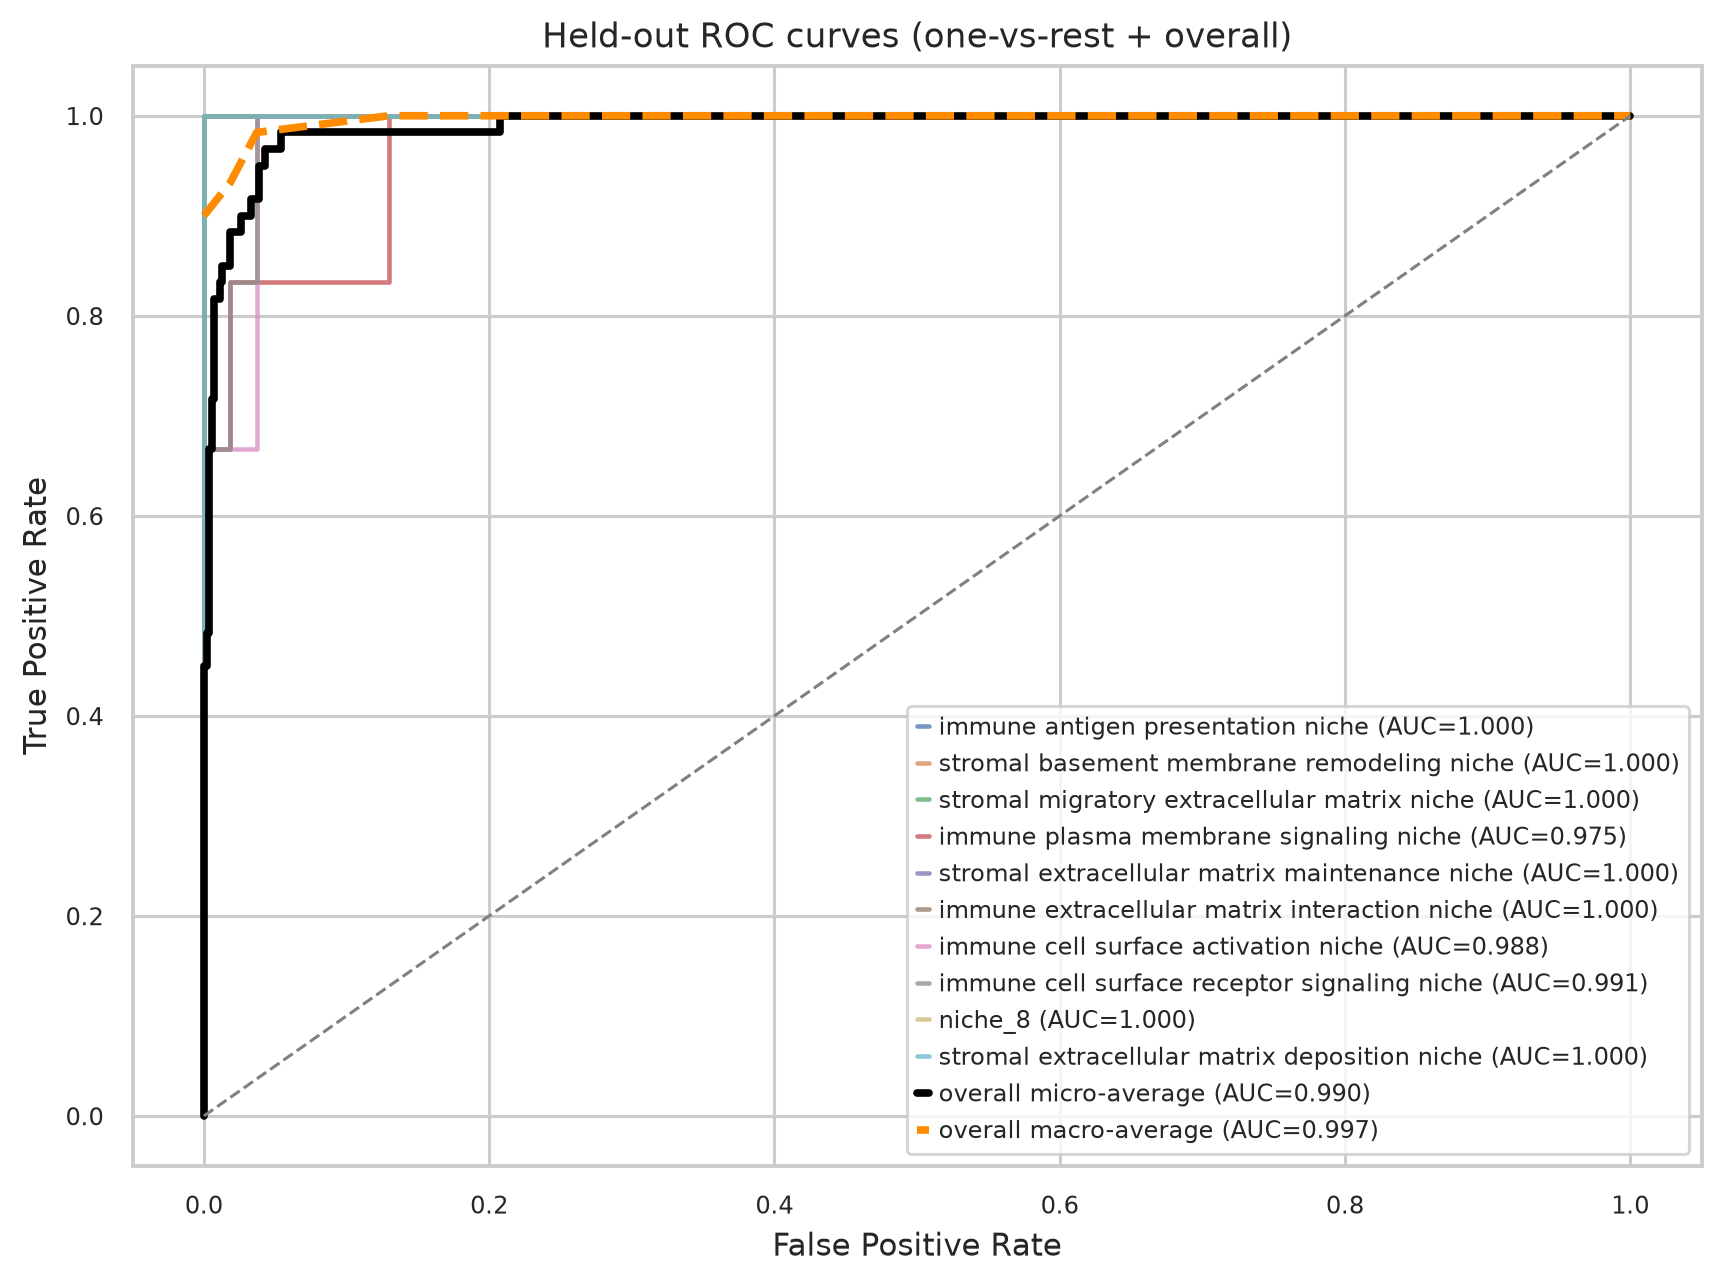


Overall held-out test results (seen-label subset)
Target name: niche_label
Accuracy: 0.9000
Macro F1: 0.8976
Overall ROC-AUC (micro): 0.9899
Overall ROC-AUC (macro): 0.9969
Evaluated held-out samples: 6 / 6
Excluded held-out samples from supervised scoring: 0
Excluded held-out rows with unseen labels: 0
                                  sample_id  n_vectors  accuracy  macro_f1
Human_Breast_Biomarkers_S3_Bot_he_image.ome         10       0.8  0.733333
Human_Breast_Biomarkers_S3_Mid_he_image.ome         10       0.9  0.866667
Human_Breast_Biomarkers_S3_Top_he_image.ome         10       1.0  1.000000
Human_Breast_Biomarkers_S4_Bot_he_image.ome         10       1.0  1.000000
Human_Breast_Biomarkers_S4_Mid_he_image.ome         10       0.7  0.616667
Human_Breast_Biomarkers_S4_Top_he_image.ome         10       1.0  1.000000

Confusion matrix (row-normalized %, true class on rows):
                                                immune antigen presentation niche  stromal basement membrane re

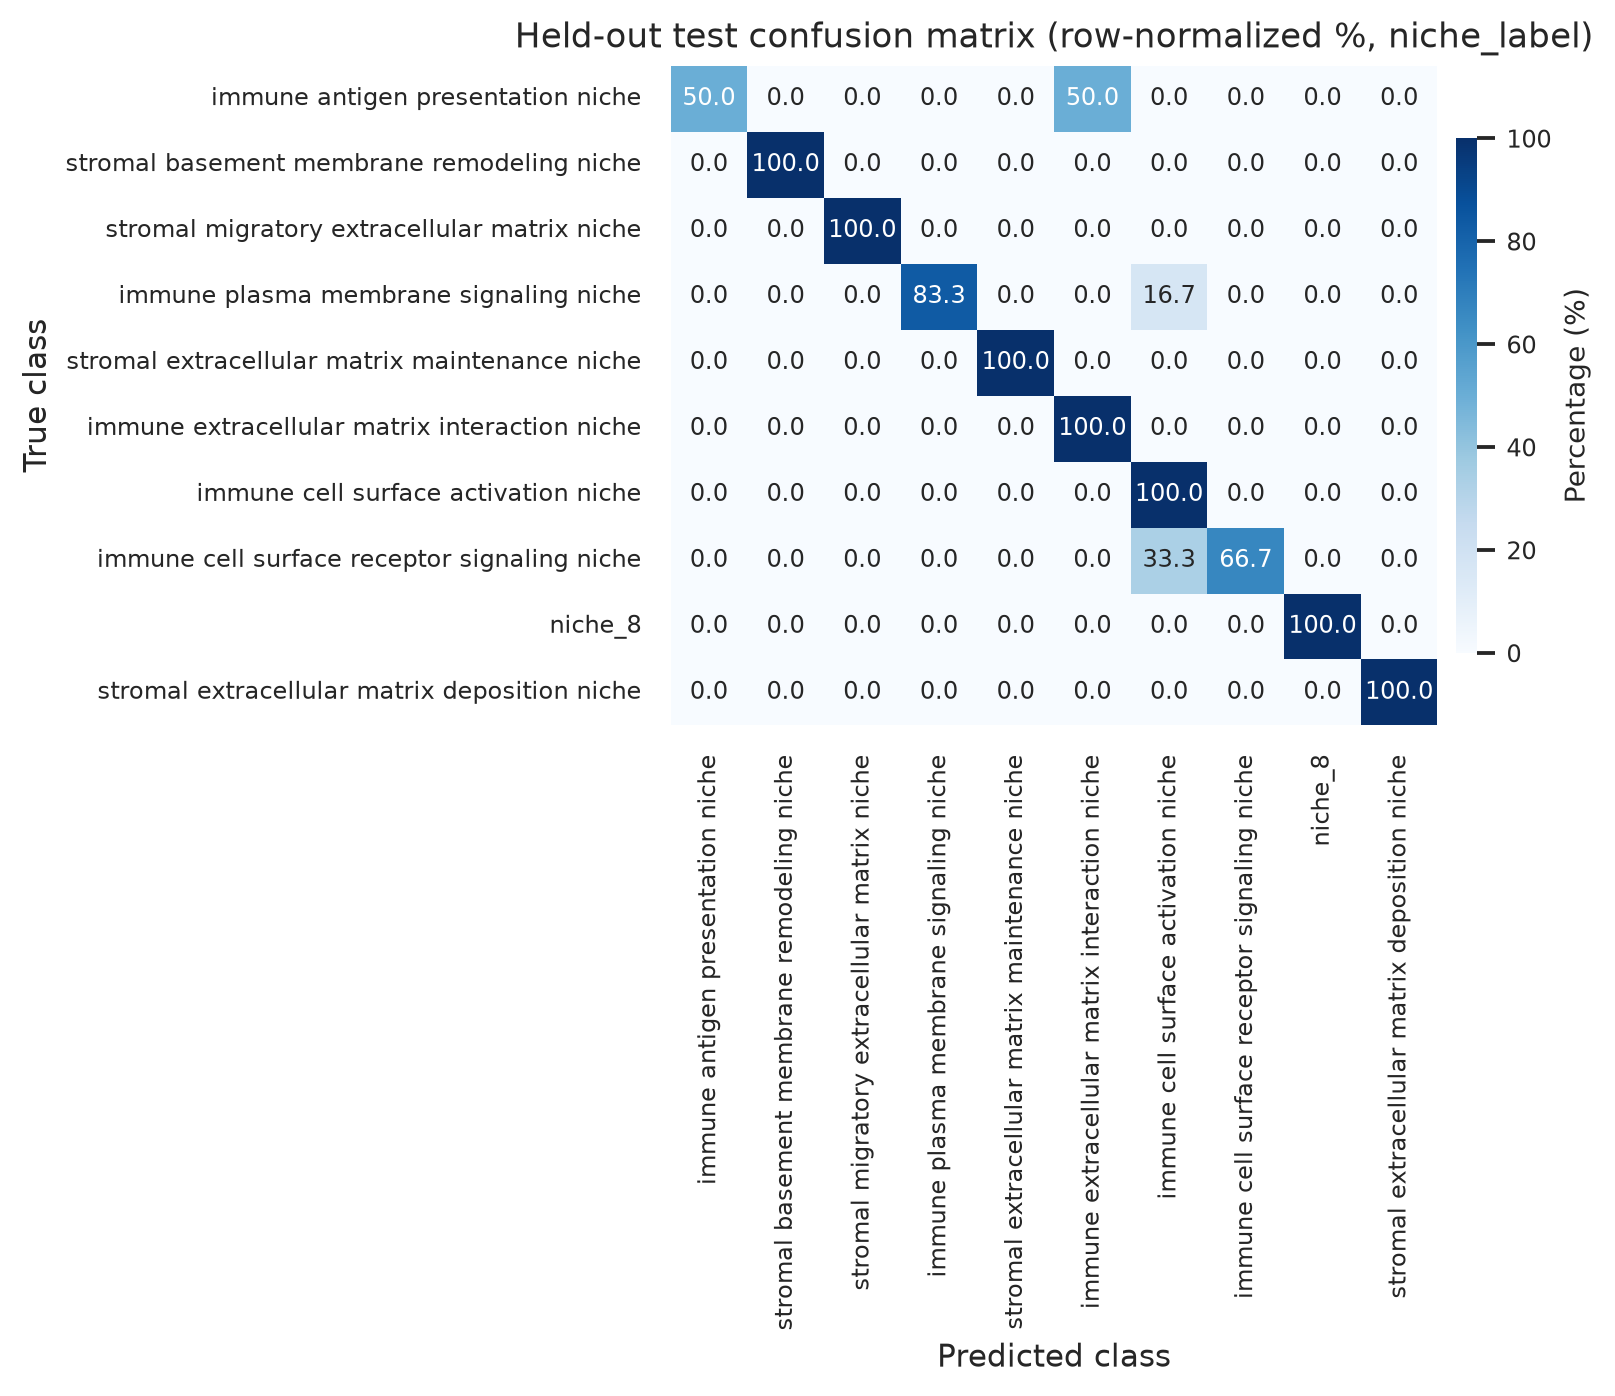

Saved figure: outputs/v3/nn_sample_split/test_roc_curves.png
Saved figure: outputs/v3/nn_sample_split/test_confusion_matrix_heatmap.png


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Overall metrics across all evaluable held-out rows.
overall_acc = accuracy_score(all_test_true, all_test_pred)
overall_f1 = f1_score(all_test_true, all_test_pred, average="macro")

# Build display labels for ROC plots/tables.
# If class names look like niche IDs (e.g., niche_3), map them to obtained niche labels.
display_name_map = {}
if "niche_labels_df" in globals() and isinstance(niche_labels_df, pd.DataFrame):
    if {"niche_group", "niche_label"}.issubset(set(niche_labels_df.columns)):
        display_name_map = dict(
            zip(
                niche_labels_df["niche_group"].astype(str),
                niche_labels_df["niche_label"].astype(str),
            )
        )
elif "CFG" in globals() and "outdir" in CFG:
    label_csv = Path(CFG["outdir"]) / "niche_labels_by_niche.csv"
    if label_csv.exists():
        tmp_df = pd.read_csv(label_csv)
        if {"niche_group", "niche_label"}.issubset(set(tmp_df.columns)):
            display_name_map = dict(zip(tmp_df["niche_group"].astype(str), tmp_df["niche_label"].astype(str)))

raw_display_names = [display_name_map.get(str(name), str(name)) for name in class_names]

# Ensure display names are unique for readability.
name_counts = pd.Series(raw_display_names).value_counts().to_dict()
class_display_names = []
for base_name, class_name in zip(raw_display_names, class_names):
    if name_counts.get(base_name, 0) > 1:
        class_display_names.append(f"{class_name} | {base_name}")
    else:
        class_display_names.append(base_name)

# One-vs-rest ROC-AUC curves for multiclass evaluation.
# We also compute overall micro-average and macro-average AUC.
y_true_bin = label_binarize(all_test_true, classes=np.arange(num_classes))
roc_auc_scores = {}

per_class_curves = []
for idx, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, idx], all_test_prob[:, idx])
    roc_auc_value = auc(fpr, tpr)
    roc_auc_scores[class_name] = float(roc_auc_value)
    display_name = class_display_names[idx]
    per_class_curves.append((fpr, tpr, display_name, roc_auc_value))

# Overall micro-average ROC/AUC pools all class decisions together.
fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), all_test_prob.ravel())
roc_auc_micro = float(auc(fpr_micro, tpr_micro))

# Overall macro-average ROC/AUC averages class ROC curves equally.
all_fpr = np.unique(np.concatenate([curve[0] for curve in per_class_curves]))
mean_tpr = np.zeros_like(all_fpr)
for fpr, tpr, _, _ in per_class_curves:
    mean_tpr += np.interp(all_fpr, fpr, tpr)
mean_tpr /= num_classes
roc_auc_macro = float(auc(all_fpr, mean_tpr))

fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
for fpr, tpr, display_name, roc_auc_value in per_class_curves:
    ax_roc.plot(fpr, tpr, label=f"{display_name} (AUC={roc_auc_value:.3f})", alpha=0.75)

# Highlight overall ROC curves.
ax_roc.plot(
    fpr_micro,
    tpr_micro,
    linestyle="-",
    linewidth=2.5,
    color="black",
    label=f"overall micro-average (AUC={roc_auc_micro:.3f})",
)
ax_roc.plot(
    all_fpr,
    mean_tpr,
    linestyle="--",
    linewidth=2.5,
    color="darkorange",
    label=f"overall macro-average (AUC={roc_auc_macro:.3f})",
)

ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
ax_roc.set_xlabel("False Positive Rate", fontsize=10)
ax_roc.set_ylabel("True Positive Rate", fontsize=10)
ax_roc.set_title("Held-out ROC curves (one-vs-rest + overall)", fontsize=11)
ax_roc.tick_params(axis="x", labelsize=8)
ax_roc.tick_params(axis="y", labelsize=8)
ax_roc.legend(loc="lower right", fontsize=8, title_fontsize=8)
fig_roc.tight_layout()

roc_auc_df = pd.DataFrame(
    {
        "class_name": class_display_names + ["overall_micro", "overall_macro"],
        "roc_auc": list(roc_auc_scores.values()) + [roc_auc_micro, roc_auc_macro],
    }
)
roc_auc_df.to_csv(sample_split_dir / "test_roc_auc.csv", index=False)
fig_roc.savefig(sample_split_dir / "test_roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

# Save pooled prediction and metric artifacts for the held-out set.
overall_pred_df = pd.concat(
    [
        pd.DataFrame({"y_true": all_test_true, "y_pred": all_test_pred}),
        pd.DataFrame(all_test_prob, columns=[f"prob_{name}" for name in class_names]),
    ],
    axis=1,
)
overall_pred_df.to_csv(sample_split_dir / "test_predictions_all.csv", index=False)

print("\nOverall held-out test results (seen-label subset)")
print("Target name: niche_label")
print(f"Accuracy: {overall_acc:.4f}")
print(f"Macro F1: {overall_f1:.4f}")
print(f"Overall ROC-AUC (micro): {roc_auc_micro:.4f}")
print(f"Overall ROC-AUC (macro): {roc_auc_macro:.4f}")
print(test_summary_df.to_string(index=False))
print("\nROC-AUC per class + overall:")
print(roc_auc_df.to_string(index=False))
print("Saved figure:", sample_split_dir / "test_roc_curves.png")

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Overall confusion-matrix metrics across all evaluable held-out rows.
overall_cm = confusion_matrix(all_test_true, all_test_pred, labels=np.arange(num_classes))
overall_cm_pct = confusion_matrix(
    all_test_true,
    all_test_pred,
    labels=np.arange(num_classes),
    normalize="true",
)
overall_report = classification_report(
    all_test_true,
    all_test_pred,
    labels=np.arange(num_classes),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

# Build display labels for plots/tables.
# If class names look like niche IDs (e.g., niche_3), map them to obtained niche labels.
display_name_map = {}
if "niche_labels_df" in globals() and isinstance(niche_labels_df, pd.DataFrame):
    if {"niche_group", "niche_label"}.issubset(set(niche_labels_df.columns)):
        display_name_map = dict(
            zip(
                niche_labels_df["niche_group"].astype(str),
                niche_labels_df["niche_label"].astype(str),
            )
        )
elif "CFG" in globals() and "outdir" in CFG:
    label_csv = Path(CFG["outdir"]) / "niche_labels_by_niche.csv"
    if label_csv.exists():
        tmp_df = pd.read_csv(label_csv)
        if {"niche_group", "niche_label"}.issubset(set(tmp_df.columns)):
            display_name_map = dict(zip(tmp_df["niche_group"].astype(str), tmp_df["niche_label"].astype(str)))

raw_display_names = [display_name_map.get(str(name), str(name)) for name in class_names]

# Ensure display names are unique for readability.
name_counts = pd.Series(raw_display_names).value_counts().to_dict()
class_display_names = []
for base_name, class_name in zip(raw_display_names, class_names):
    if name_counts.get(base_name, 0) > 1:
        class_display_names.append(f"{class_name} | {base_name}")
    else:
        class_display_names.append(base_name)

cm_pct_df = pd.DataFrame(overall_cm_pct, index=class_display_names, columns=class_display_names)
cm_pct_df.to_csv(sample_split_dir / "test_confusion_matrix.csv")

# Keep raw counts in a separate file for traceability.
pd.DataFrame(overall_cm, index=class_names, columns=class_names).to_csv(
    sample_split_dir / "test_confusion_matrix_counts.csv"
)
pd.DataFrame(overall_report).T.to_csv(sample_split_dir / "test_classification_report.csv")

# Coverage reporting should use the fixed held-out sample list, not any stale in-memory table.
excluded_rows = int(len(excluded_unseen_df))
evaluated_test_samples = sorted(test_summary_df["sample_id"].unique().tolist())
excluded_test_samples = sorted(set(CFG["test_sample_stems"]) - set(evaluated_test_samples))

print("\nConfusion matrix (row-normalized %, true class on rows):")
print((cm_pct_df * 100).round(2).to_string())
print("\nHeld-out coverage")
print(f"Evaluated held-out samples: {len(evaluated_test_samples)} / {len(CFG['test_sample_stems'])}")
print(f"Excluded held-out samples from supervised scoring: {len(excluded_test_samples)}")
print(f"Excluded held-out rows with unseen labels: {excluded_rows}")

# Visualization: normalized confusion-matrix heatmap in percentage units.
try:
    fig_cm, ax_cm = plt.subplots(figsize=(7.5, 6.5))
    ax = sns.heatmap(
        cm_pct_df * 100,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        xticklabels=class_display_names,
        yticklabels=class_display_names,
        vmin=0,
        vmax=100,
        cbar_kws={"label": "Percentage (%)", "shrink": 0.78, "aspect": 24, "pad": 0.02},
        annot_kws={"size": 8},
        ax=ax_cm,
    )
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label("Percentage (%)", size=9)
    ax.set_xlabel("Predicted class", fontsize=10)
    ax.set_ylabel("True class", fontsize=10)
    ax.set_title("Held-out test confusion matrix (row-normalized %, niche_label)", fontsize=11)
    ax.tick_params(axis="x", labelsize=8, rotation=90)
    ax.tick_params(axis="y", labelsize=8, rotation=0)
    fig_cm.tight_layout()
    fig_cm.savefig(sample_split_dir / "test_confusion_matrix_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()
except Exception as exc:
    print("Plot skipped:", exc)

print("Saved figure:", sample_split_dir / "test_confusion_matrix_heatmap.png")

**Final Evaluation Artifacts**
What you should see: per-sample test accuracy/F1 for evaluated held-out samples, an overall held-out confusion matrix, and saved prediction tables for each evaluated test dataset.

Generated files:
- `outputs/v3/nn_sample_split/test_summary.csv`
- `outputs/v3/nn_sample_split/test_predictions_all.csv`
- `outputs/v3/nn_sample_split/test_confusion_matrix.csv`
- `outputs/v3/nn_sample_split/test_classification_report.csv`
- `outputs/v3/nn_sample_split/predictions/<sample>.csv`
- `outputs/v3/nn_sample_split/test_vectors_unseen_labels.csv`
- `outputs/v3/nn_sample_split/label_coverage_summary.csv`
- `outputs/v3/nn_sample_split/unlabeled_niche_rows_skipped.csv`

Important final variables:
- `test_summary_df`: per-sample performance table on seen-label held-out rows.
- `overall_cm`: confusion matrix on the seen-label held-out subset.
- `overall_pred_df`: pooled prediction table for the evaluated held-out subset.
- `excluded_unseen_df`: held-out rows excluded due to unseen labels.

Pipeline status: this notebook enforces 12 total samples, trains on the configured six training samples only, validates on held-out datasets with seen-label supervised metrics, allows duplicate niche labels to merge at class level, and reports seen-vs-unseen label coverage explicitly.

## Discussion and Conclusion

### Discussion
1. The pipeline now uses a true sample-level split: six training datasets and the other 6 datasets as held-out data.
2. Label construction (DE/GOEA/LLM naming) is train-only, using the same six training datasets.
3. Supervised held-out metrics are computed on the seen-label subset, and excluded unseen-label rows/samples are reported explicitly.
4. If held-out performance is weak, that usually means the model needs more diverse training slides or a less sample-specific feature representation.

### Conclusion
This notebook trains on the six configured training samples, then applies the model to the remaining held-out datasets while transparently reporting which rows/samples are evaluable under seen-label supervision.